## Lasso

In [2]:
# ==============================================================================
# [CELL 1] MODEL 1 (EARNINGS DAY) - ABSOLUTE MODELING SETUP
# ==============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from sklearn.linear_model import ElasticNetCV, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.api as sm
import os

try:
    from pmdarima import auto_arima
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False

PD_VER = int(pd.__version__.split(".")[0])
Q_FREQ = "QE" if PD_VER >= 2 else "Q"

print(">>> [Cell 1] Building feature pool for Model 1 (Earnings Day Forecasts)...")

def clean_num(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, float)): return float(x)
    s = str(x).strip().replace(",", "").replace("$", "").replace(" ", "")
    if s in ["—", "", "-", "NA", "N/A", "nan", "NaN"]: return np.nan
    if s.startswith("(") and s.endswith(")"): s = "-" + s[1:-1]
    try: return float(s)
    except Exception: return np.nan

file_hist = "Complete_UC2_Forecast_Data.xlsx"
raw_df = pd.read_excel(file_hist, sheet_name="Forecast Data", header=1)

cols_to_clean = ["PCL_t+1", "PCL_t", "Sent_BART_t", "Fcst_GDP_YoY_for_t+1", "Fcst_Unemp_Q_for_t+1", "Fcst_BoC_for_t+1", "GDP_YoY_t", "Overnight_Rate_t"]
for c in cols_to_clean:
    if c in raw_df.columns: raw_df[c] = raw_df[c].apply(clean_num)

raw_df = raw_df.sort_values(by=["Bank", "Year", "Quarter"])
cols_to_fill = ["PCL_t", "Sent_BART_t", "Fcst_GDP_YoY_for_t+1", "Fcst_Unemp_Q_for_t+1", "Fcst_BoC_for_t+1"]
for c in cols_to_fill:
    if c in raw_df.columns: raw_df[c] = raw_df.groupby("Bank")[c].transform(lambda x: x.ffill().bfill())

def sum_safe(x): return x.sum(min_count=1)
agg_funcs = {"PCL_t+1": sum_safe, "PCL_t": sum_safe, "Sent_BART_t": "mean", "Fcst_GDP_YoY_for_t+1": "mean", "Fcst_Unemp_Q_for_t+1": "mean", "Fcst_BoC_for_t+1": "mean", "GDP_YoY_t": "mean", "Overnight_Rate_t": "mean"}
agg_funcs = {k: v for k, v in agg_funcs.items() if k in raw_df.columns}

agg_df = raw_df.groupby(["Year", "Quarter"], as_index=False).agg(agg_funcs)
q_map = {"Q1": "03-31", "Q2": "06-30", "Q3": "09-30", "Q4": "12-31"}
agg_df.index = pd.DatetimeIndex(agg_df["Year"].fillna(0).astype(int).astype(str) + "-" + agg_df["Quarter"].map(q_map))
agg_df = agg_df.sort_index().asfreq(Q_FREQ)
agg_df = agg_df[agg_df.index <= "2026-03-31"]

agg_df["M1_BART_x_GDP"] = agg_df["Sent_BART_t"] * agg_df["Fcst_GDP_YoY_for_t+1"]
agg_df["M1_BART_x_Unemp"] = agg_df["Sent_BART_t"] * agg_df["Fcst_Unemp_Q_for_t+1"]
agg_df["M1_BART_x_BoC"] = agg_df["Sent_BART_t"] * agg_df["Fcst_BoC_for_t+1"]

candidate_features_m1 = ["PCL_t", "Sent_BART_t", "Fcst_GDP_YoY_for_t+1", "Fcst_Unemp_Q_for_t+1", "Fcst_BoC_for_t+1", "M1_BART_x_GDP", "M1_BART_x_Unemp", "M1_BART_x_BoC"]
features_ts_hist = ["GDP_YoY_t", "Overnight_Rate_t"] 

model1_df = agg_df[["PCL_t+1", "Year", "Quarter"] + candidate_features_m1 + features_ts_hist].copy()

print(f"✅ Cell 1 (Model 1) Complete! Actual PCL_t (2026 Q1): ${model1_df['PCL_t'].dropna().iloc[-1]:,.0f}M")

>>> [Cell 1] Building feature pool for Model 1 (Earnings Day Forecasts)...
✅ Cell 1 (Model 1) Complete! Actual PCL_t (2026 Q1): $4,619M



>>> [Cell 2&3] Executing Model 1 ML Pipeline (Lasso Enabled)...

🔍 PROCESS 1: MODEL 1 LASSO FEATURE SELECTION
  ✅ KEPT     : PCL_t                               (Weight:   849.01)
  ❌ PRUNED   : Sent_BART_t                         (Weight:    -0.00)
  ❌ PRUNED   : Fcst_GDP_YoY_for_t+1                (Weight:    -0.00)
  ❌ PRUNED   : Fcst_Unemp_Q_for_t+1                (Weight:     0.00)
  ❌ PRUNED   : Fcst_BoC_for_t+1                    (Weight:     0.00)
  ❌ PRUNED   : M1_BART_x_GDP                       (Weight:    -0.00)
  ❌ PRUNED   : M1_BART_x_Unemp                     (Weight:    -0.00)
  ❌ PRUNED   : M1_BART_x_BoC                       (Weight:     0.00)

⚠️ Lasso was too aggressive. Forcing fallback features for Dashboard compatibility.

🎯 MODEL 1: 7-MODEL SCORECARD (Global Champion Selection)


Model,OOS R2,OOS MAPE,OOS RMSE
03. TimeSeries: VAR,-0.4267,11.93%,623.4
01. Baseline: Naive (Last Qtr),-1.1770,14.52%,770.1
02. TimeSeries: SARIMA,-1.1770,14.52%,770.1
04. ML: Lasso,-2.3931,18.87%,961.4
05. ML: Ridge,-2.6874,19.06%,1002.2
07. ML: Gradient Boosting,-4.7411,22.16%,1250.5
06. ML: Random Forest,-5.0087,22.31%,1279.4



📘 MODEL 1 TABLE 1: GLOBAL CHAMPION vs NAIVE


Metric,Champion (03. TimeSeries: VAR),Naive Baseline,Improvement
OOS R²,-0.4267,-1.1770,+0.7504
OOS MAPE (%),11.9257,14.5193,-2.5937
OOS RMSE ($M),623.3877,770.0752,-146.6875


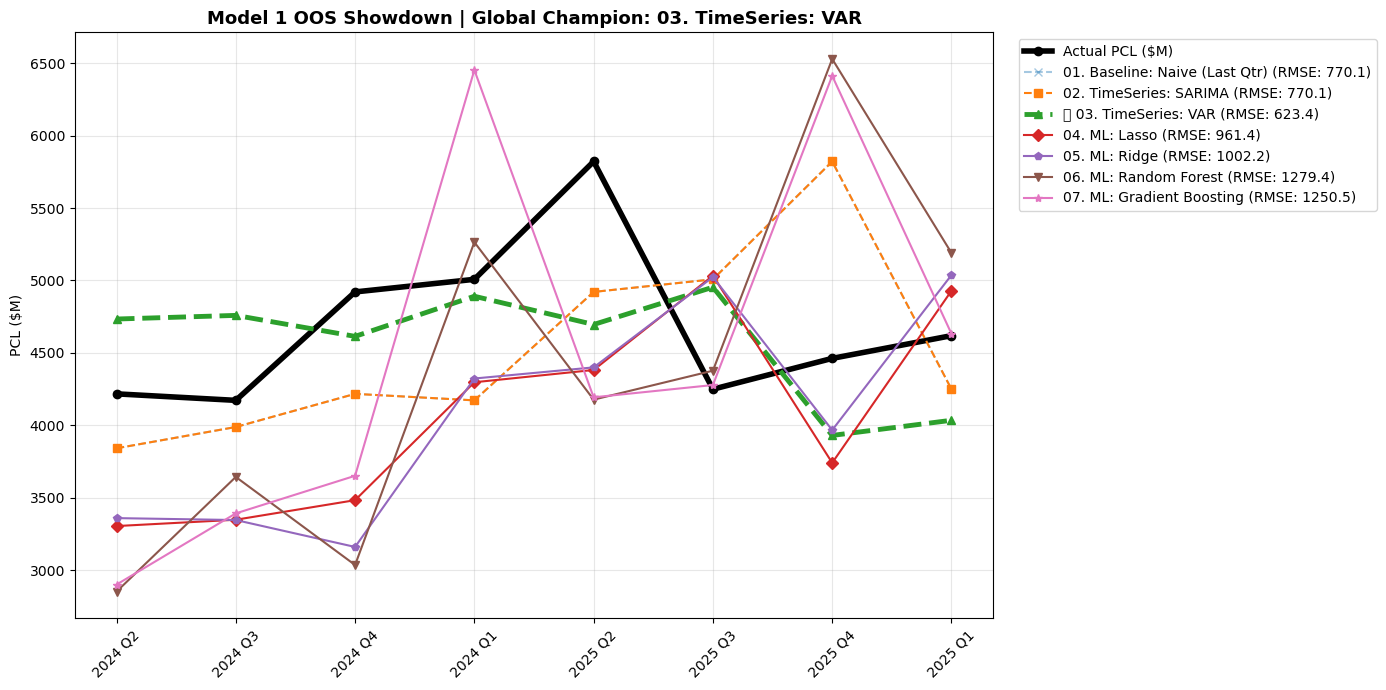

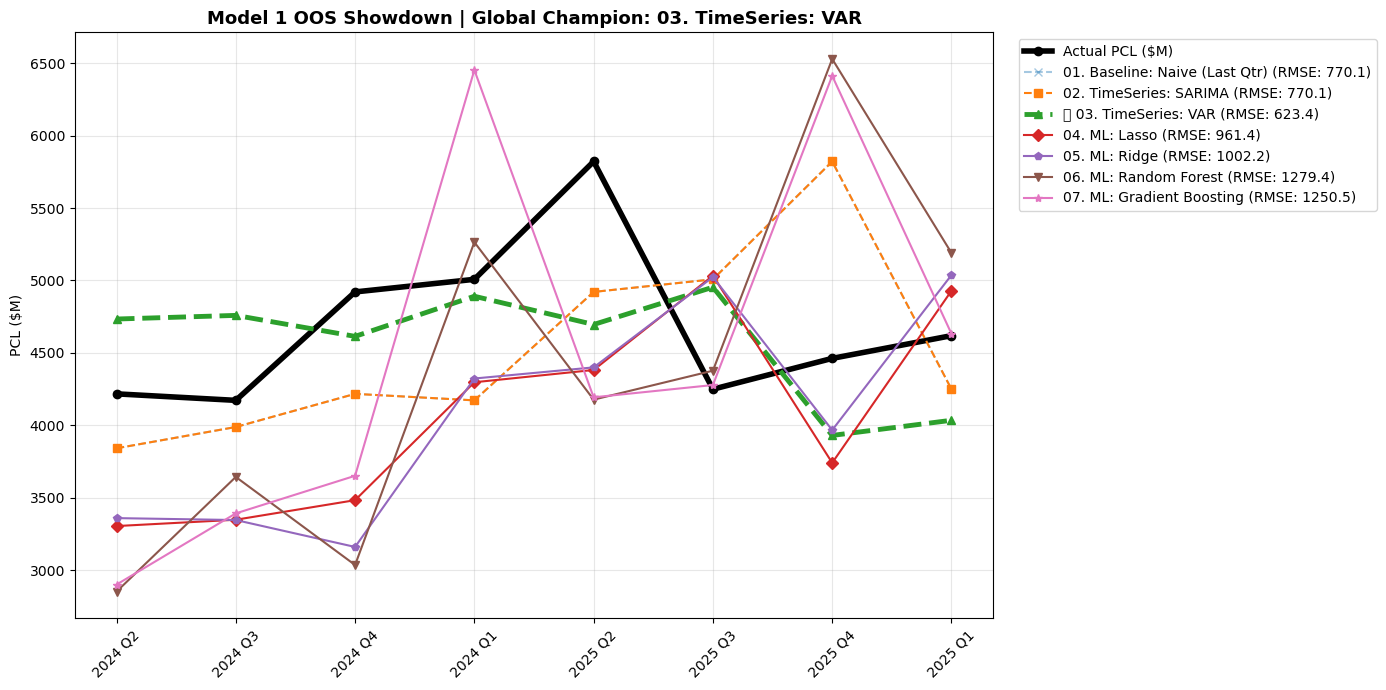

In [3]:
# ==============================================================================
# [CELL 2&3] MODEL 1 - LASSO SELECTION & GLOBAL OOS SHOWDOWN
# ==============================================================================
print(f"\n>>> [Cell 2&3] Executing Model 1 ML Pipeline (Lasso Enabled)...\n")

train_valid_df1 = model1_df.dropna(subset=["PCL_t+1"]).copy()

# 🎯 PROCESS 1: LASSO FEATURE SELECTION
tscv_fs = TimeSeriesSplit(n_splits=3)
X_cand_sc1 = StandardScaler().fit_transform(train_valid_df1[candidate_features_m1])
y_full1 = train_valid_df1["PCL_t+1"].values

lasso_fs1 = LassoCV(alphas=np.logspace(-2, 4, 50), cv=tscv_fs, random_state=42).fit(X_cand_sc1, y_full1)

selected_features_m1 = []
print("="*85)
print(f"🔍 PROCESS 1: MODEL 1 LASSO FEATURE SELECTION")
print("="*85)
for feat, coef in zip(candidate_features_m1, lasso_fs1.coef_):
    status = "✅ KEPT" if abs(coef) > 1e-4 else "❌ PRUNED"
    if abs(coef) > 1e-4: selected_features_m1.append(feat)
    print(f"  {status:10s} : {feat:35s} (Weight: {coef:>8.2f})")

# Fallback in case Lasso drops everything but PCL_t
if len(selected_features_m1) <= 1: 
    print("\n⚠️ Lasso was too aggressive. Forcing fallback features for Dashboard compatibility.")
    selected_features_m1 = ["PCL_t", "Fcst_GDP_YoY_for_t+1", "Sent_BART_t"]

# 🎯 PROCESS 2: 7-MODEL OOS BACKTEST
tscv = TimeSeriesSplit(n_splits=3)
ml_models_dict = {
    "04. ML: Lasso": LassoCV(alphas=np.logspace(-2, 4, 50), cv=tscv),
    "05. ML: Ridge": RidgeCV(alphas=np.logspace(-2, 4, 50), cv=tscv),
    "06. ML: Random Forest": RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    "07. ML: Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42)
}

h_test = 8  
test_indices = list(range(len(train_valid_df1) - h_test, len(train_valid_df1)))
prediction_records1 = []

for t in test_indices:
    if t < 12: continue
    train_df, test_row = train_valid_df1.iloc[:t], train_valid_df1.iloc[t:t+1]
    y_tr_abs, y_actual = train_df["PCL_t+1"], float(test_row["PCL_t+1"].iloc[0])
    yr, qtr = int(test_row.index[0].year), f"Q{test_row.index[0].quarter + 1}" if test_row.index[0].quarter < 4 else f"Q1"
    
    def eval_mod(m_name, p_val): prediction_records1.append({'Year': yr, 'Quarter': qtr, 'Model': m_name, 'Predicted ($M)': float(np.squeeze(p_val)), 'Actual ($M)': y_actual})
    
    eval_mod("01. Baseline: Naive (Last Qtr)", train_df["PCL_t"].iloc[-1])
    try:
        if HAS_PMDARIMA: sar_p = auto_arima(y_tr_abs, X=train_df[features_ts_hist], seasonal=False, suppress_warnings=True).predict(n_periods=1, X=test_row[features_ts_hist])[0]
        else: sar_p = ARIMA(y_tr_abs.values, exog=train_df[features_ts_hist].values, order=(1,0,0)).fit().forecast(steps=1, exog=test_row[features_ts_hist].values)[0]
        eval_mod("02. TimeSeries: SARIMA", sar_p)
    except: eval_mod("02. TimeSeries: SARIMA", train_df["PCL_t"].iloc[-1])
    try: 
        var_p = VAR(train_df[["PCL_t+1"] + features_ts_hist]).fit(maxlags=1).forecast(train_df[["PCL_t+1"] + features_ts_hist].values[-1:], steps=1)[0, 0]
        eval_mod("03. TimeSeries: VAR", var_p)
    except: eval_mod("03. TimeSeries: VAR", train_df["PCL_t"].iloc[-1])

    sc = StandardScaler()
    X_tr_sc, X_te_sc = sc.fit_transform(train_df[selected_features_m1]), sc.transform(test_row[selected_features_m1])
    for m_name, model in ml_models_dict.items():
        eval_mod(m_name, model.fit(X_tr_sc, y_tr_abs).predict(X_te_sc)[0])

results_df1 = pd.DataFrame(prediction_records1)
metrics_list1 = []
for model_name, grp in results_df1.groupby("Model"):
    valid = grp.dropna(subset=["Predicted ($M)", "Actual ($M)"])
    if len(valid) > 0:
        y_a, y_p = valid["Actual ($M)"].values.astype(float), valid["Predicted ($M)"].values.astype(float)
        metrics_list1.append({"Model": model_name, "OOS R2": r2_score(y_a, y_p), "OOS MAPE": float(np.mean(np.abs((y_a - y_p) / np.abs(y_a)))) * 100, "OOS RMSE": float(np.sqrt(np.mean((y_a - y_p)**2)))})

final_table1 = pd.DataFrame(metrics_list1).sort_values(by="OOS MAPE").reset_index(drop=True)

# 🌟 WE NOW ALLOW TIME SERIES TO BE THE GLOBAL CHAMPION
global_best_m1 = final_table1.iloc[0]["Model"]
best_rmse1 = final_table1.iloc[0]["OOS RMSE"]

print("\n" + "="*85)
print("🎯 MODEL 1: 7-MODEL SCORECARD (Global Champion Selection)")
print("="*85)
display(final_table1.style.format({"OOS R2": "{:.4f}", "OOS MAPE": "{:.2f}%", "OOS RMSE": "{:.1f}"}).set_properties(**{'text-align': 'center', 'border': '1px solid black'}).hide(axis="index").background_gradient(subset=['OOS MAPE'], cmap='Blues'))

naive_stats1 = final_table1[final_table1["Model"] == "01. Baseline: Naive (Last Qtr)"].iloc[0]
champ_stats1 = final_table1.iloc[0]
table_1 = pd.DataFrame({
    "Metric": ["OOS R²", "OOS MAPE (%)", "OOS RMSE ($M)"],
    f"Champion ({global_best_m1})": [champ_stats1["OOS R2"], champ_stats1["OOS MAPE"], champ_stats1["OOS RMSE"]],
    "Naive Baseline": [naive_stats1["OOS R2"], naive_stats1["OOS MAPE"], naive_stats1["OOS RMSE"]]
})
table_1["Improvement"] = table_1[f"Champion ({global_best_m1})"] - table_1["Naive Baseline"]

print("\n" + "="*85)
print(f"📘 MODEL 1 TABLE 1: GLOBAL CHAMPION vs NAIVE")
print("="*85)
display(table_1.style.format({f"Champion ({global_best_m1})": "{:.4f}", "Naive Baseline": "{:.4f}", "Improvement": "{:+.4f}"}).set_properties(**{'text-align': 'center', 'border': '1px solid black'}).hide(axis="index"))

plt.close('all'); fig_sd, ax_sd = plt.subplots(figsize=(14, 7))
detail_df = results_df1[results_df1["Model"] == global_best_m1]
time_labels = [f"{y} {q}" for y, q in zip(detail_df["Year"], detail_df["Quarter"])]
x_ticks_sd = np.arange(len(time_labels))
ax_sd.plot(x_ticks_sd, detail_df["Actual ($M)"].values, 'k-o', label="Actual PCL ($M)", linewidth=4.0)
colors, markers = sns.color_palette("tab10", len(metrics_list1)), ['x', 's', '^', 'D', 'p', 'v', '*', 'h']
for i, m_name in enumerate(sorted(final_table1["Model"])):
    m_data = results_df1[results_df1["Model"] == m_name]
    lw = 3.5 if m_name == global_best_m1 else 1.5
    ax_sd.plot(x_ticks_sd, m_data["Predicted ($M)"].values, linestyle='--' if 'Baseline' in m_name or 'TimeSeries' in m_name else '-', marker=markers[i%len(markers)], color=colors[i], label=f"{'🏆 ' if m_name == global_best_m1 else ''}{m_name} (RMSE: {final_table1[final_table1['Model'] == m_name]['OOS RMSE'].iloc[0]:.1f})", linewidth=lw, alpha=0.4 if 'Naive' in m_name else 1.0)
ax_sd.set_xticks(x_ticks_sd); ax_sd.set_xticklabels(time_labels, rotation=45)
ax_sd.set_title(f"Model 1 OOS Showdown | Global Champion: {global_best_m1}", fontweight="bold", fontsize=13); ax_sd.set_ylabel("PCL ($M)"); ax_sd.grid(True, alpha=0.3); ax_sd.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)
plt.tight_layout(); display(fig_sd)

# Model 1 (Quarter / Earnings Day Data)

In [15]:
# ==============================================================================
# [CELL 1] MODEL 1 (EARNINGS DAY) - ABSOLUTE MODELING SETUP & KNN IMPUTATION
# ==============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import sklearn
from sklearn.impute import KNNImputer
from sklearn.linear_model import ElasticNetCV, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.api as sm
import os

try: from pmdarima import auto_arima; HAS_PMDARIMA = True
except ImportError: HAS_PMDARIMA = False

try: from xgboost import XGBRegressor; HAS_XGB = True
except ImportError: HAS_XGB = False

try: from lightgbm import LGBMRegressor; HAS_LGBM = True
except ImportError: HAS_LGBM = False

PD_VER = int(pd.__version__.split(".")[0])
Q_FREQ = "QE" if PD_VER >= 2 else "Q"

print(">>> [Cell 1] Building feature pool for Model 1 (Earnings Day Forecasts)...")

def clean_num(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, float)): return float(x)
    s = str(x).strip().replace(",", "").replace("$", "").replace(" ", "")
    if s in ["—", "", "-", "NA", "N/A", "nan", "NaN"]: return np.nan
    if s.startswith("(") and s.endswith(")"): s = "-" + s[1:-1]
    try: return float(s)
    except Exception: return np.nan

file_hist = "Complete_UC2_Forecast_Data.xlsx"
raw_df = pd.read_excel(file_hist, sheet_name="Forecast Data", header=1)

cols_to_clean = ["PCL_t+1", "PCL_t", "Sent_BART_t", "Fcst_GDP_YoY_for_t+1", "Fcst_Unemp_Q_for_t+1", "Fcst_BoC_for_t+1", "GDP_YoY_t", "Overnight_Rate_t"]
for c in cols_to_clean:
    if c in raw_df.columns: raw_df[c] = raw_df[c].apply(clean_num)

raw_df = raw_df.sort_values(by=["Bank", "Year", "Quarter"])
cols_to_fill = ["PCL_t", "Sent_BART_t", "Fcst_GDP_YoY_for_t+1", "Fcst_Unemp_Q_for_t+1", "Fcst_BoC_for_t+1"]

# 1. 内部时序填补 (Forward/Backward Fill)
for c in cols_to_fill:
    if c in raw_df.columns: 
        raw_df[c] = raw_df.groupby("Bank")[c].transform(lambda x: x.ffill().bfill())

def sum_safe(x): return x.sum(min_count=1)
agg_funcs = {"PCL_t+1": sum_safe, "PCL_t": sum_safe, "Sent_BART_t": "mean", "Fcst_GDP_YoY_for_t+1": "mean", "Fcst_Unemp_Q_for_t+1": "mean", "Fcst_BoC_for_t+1": "mean", "GDP_YoY_t": "mean", "Overnight_Rate_t": "mean"}
agg_funcs = {k: v for k, v in agg_funcs.items() if k in raw_df.columns}

# 加总为全行业数据
agg_df = raw_df.groupby(["Year", "Quarter"], as_index=False).agg(agg_funcs)
q_map = {"Q1": "03-31", "Q2": "06-30", "Q3": "09-30", "Q4": "12-31"}
agg_df.index = pd.DatetimeIndex(agg_df["Year"].fillna(0).astype(int).astype(str) + "-" + agg_df["Quarter"].map(q_map))
agg_df = agg_df.sort_index().asfreq(Q_FREQ)
agg_df = agg_df[agg_df.index <= "2026-03-31"]

candidate_features_m1 = ["PCL_t", "Sent_BART_t", "Fcst_GDP_YoY_for_t+1", "Fcst_Unemp_Q_for_t+1", "Fcst_BoC_for_t+1"]
features_ts_hist = ["GDP_YoY_t", "Overnight_Rate_t"] 
features_to_impute = candidate_features_m1 + features_ts_hist

# 🌟 2. 行业级 KNN 截面填补 (智能解决宏观预期集体缺失问题)
knn_imputer = KNNImputer(n_neighbors=3, weights='distance')
agg_df[features_to_impute] = knn_imputer.fit_transform(agg_df[features_to_impute])

# 构建乘数交互项 (需在 KNN 填补之后进行)
agg_df["M1_BART_x_GDP"] = agg_df["Sent_BART_t"] * agg_df["Fcst_GDP_YoY_for_t+1"]
agg_df["M1_BART_x_Unemp"] = agg_df["Sent_BART_t"] * agg_df["Fcst_Unemp_Q_for_t+1"]
agg_df["M1_BART_x_BoC"] = agg_df["Sent_BART_t"] * agg_df["Fcst_BoC_for_t+1"]

candidate_features_m1.extend(["M1_BART_x_GDP", "M1_BART_x_Unemp", "M1_BART_x_BoC"])
model1_df = agg_df[["PCL_t+1", "Year", "Quarter"] + candidate_features_m1 + features_ts_hist].copy()

print(f"✅ Cell 1 (Model 1) Complete! KNN Imputation applied. Actual PCL_t (2026 Q1): ${model1_df['PCL_t'].dropna().iloc[-1]:,.0f}M")

>>> [Cell 1] Building feature pool for Model 1 (Earnings Day Forecasts)...
✅ Cell 1 (Model 1) Complete! KNN Imputation applied. Actual PCL_t (2026 Q1): $4,619M



>>> [Cell 2&3] Executing Model 1 Pipeline (14-Model Showdown)...

🔍 PROCESS 1: MODEL 1 ELASTIC NET FEATURE SELECTION
  ✅ KEPT     : PCL_t                               (Weight:   584.57)
  ✅ KEPT     : Sent_BART_t                         (Weight:   -47.27)
  ✅ KEPT     : Fcst_GDP_YoY_for_t+1                (Weight:  -208.77)
  ✅ KEPT     : Fcst_Unemp_Q_for_t+1                (Weight:   137.87)
  ✅ KEPT     : Fcst_BoC_for_t+1                    (Weight:   267.24)
  ✅ KEPT     : M1_BART_x_GDP                       (Weight:  -251.48)
  ✅ KEPT     : M1_BART_x_Unemp                     (Weight:   112.56)
  ✅ KEPT     : M1_BART_x_BoC                       (Weight:   284.31)

🎯 STEP 1: MODEL 1 SCORECARD (Categorized by Scenario Utility)



⚖️ STEP 2: TRADE-OFF & ABLATION ANALYSIS


Metric,🏆 Sentiment ML (Random Forest),📉 Pure Macro (Random Forest),📏 Naive Baseline,Sentiment Value Add
In-Sample R² (Fit),0.8810,0.8612,0.3495,+0.0198
OOS R² (Testing),-3.3782,-1.9618,-1.1770,-1.4164
OOS MAPE (%),17.8798,15.1839,14.5193,+2.6959
OOS RMSE ($M),1092.0554,898.2063,770.0752,+193.8491



📄 STEP 3: DETAILED OOS PREDICTIONS (ALL 14 MODELS CROSS-COMPARISON)


Year,Quarter,Actual ($M),01. Baseline: Naive (Last Qtr),02. TS: SARIMA (Blind),03. TS: VAR (Blind),04. TS: ARIMAX (Macro+Sent),05. TS: VARMAX (Macro+Sent),06. ML: Ridge,07. ML: Elastic Net,08. ML: Random Forest,09. ML: Gradient Boosting,10. ML: XGBoost,11. ML: LightGBM,12. ML: Pure Macro (Random Forest),13. TS: ARIMAX (Pure Macro),14. TS: VARMAX (Pure Macro)
2024,Q2,"4,217.0","3,841.0","3,841.0","4,733.8","3,644.7","5,458.5","3,936.5","3,887.8","3,211.9","3,258.7","3,675.3","2,509.1","3,492.4","3,874.8","4,918.8"
2024,Q3,"4,172.0","3,988.0","3,988.0","4,758.9","3,699.6","4,571.1","3,756.9","3,732.7","3,469.0","3,489.2","3,476.6","2,574.8","3,539.1","3,624.8","4,417.4"
2024,Q4,"4,921.0","4,217.0","4,217.0","4,614.0","3,239.8","5,813.2","3,541.7","3,467.2","2,951.1","3,607.6","3,971.1","2,634.0","3,495.5","3,463.9","5,203.8"
2025,Q1,"5,008.0","4,172.0","4,172.0","4,891.1","2,832.3","5,581.4","3,553.0","3,440.5","5,036.5","5,321.2","4,588.3","2,715.6","4,046.3","3,427.4","5,287.7"
2025,Q2,"5,822.0","4,921.0","4,921.0","4,696.0","3,172.8","4,612.4","3,666.9","3,485.8","4,190.1","4,627.0","4,608.6","2,794.7","4,279.1","3,612.1","4,307.4"
2025,Q3,"4,249.0","5,008.0","5,008.0","4,953.6","4,138.9","3,316.7","4,249.9","4,111.3","4,510.3","5,014.2","4,829.8","2,895.6","4,466.1","4,563.4","3,790.9"
2025,Q4,"4,462.0","5,822.0","5,822.0","3,929.8","3,202.9","3,008.6","3,588.4","3,278.4","5,654.6","6,624.0","7,207.7","2,939.3","4,408.3","3,638.0","3,366.6"
2026,Q1,"4,619.0","4,249.0","4,249.0","4,034.4","3,217.6","3,370.2","3,740.3","3,416.4","4,579.8","3,835.8","3,596.7","2,986.8","4,243.3","3,521.4","4,124.8"


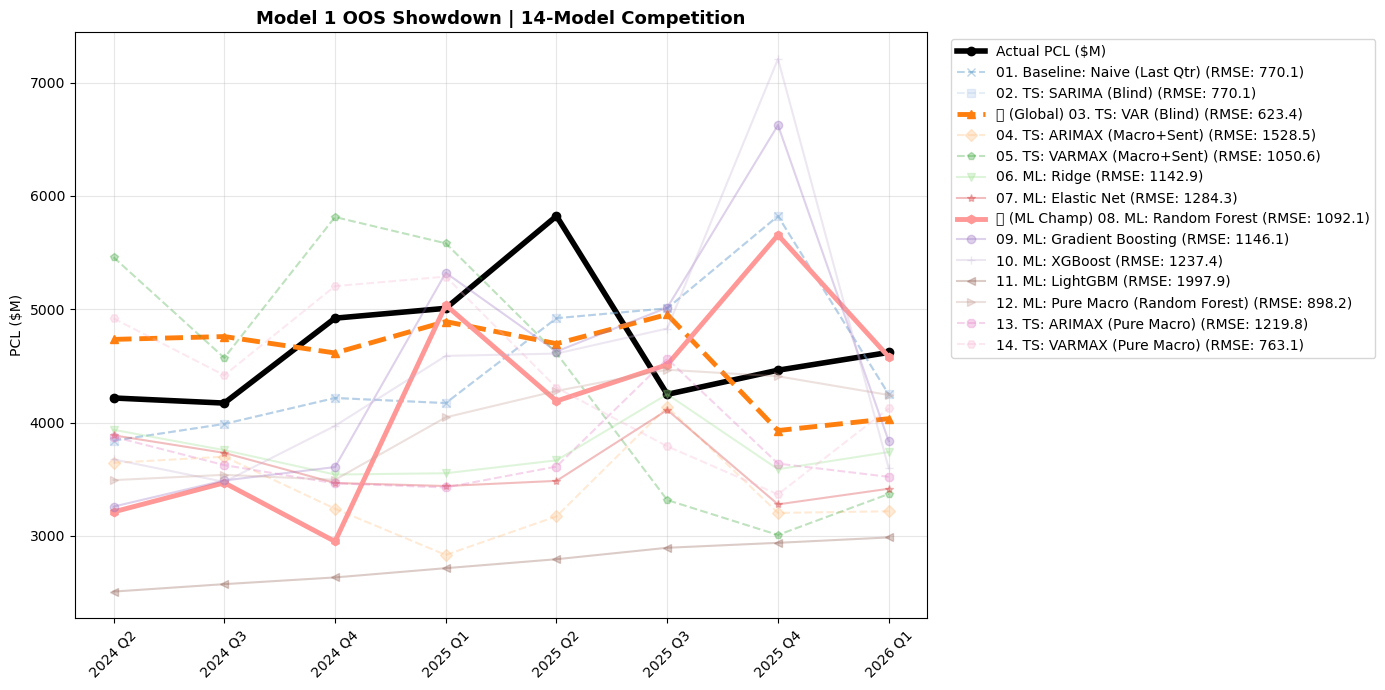

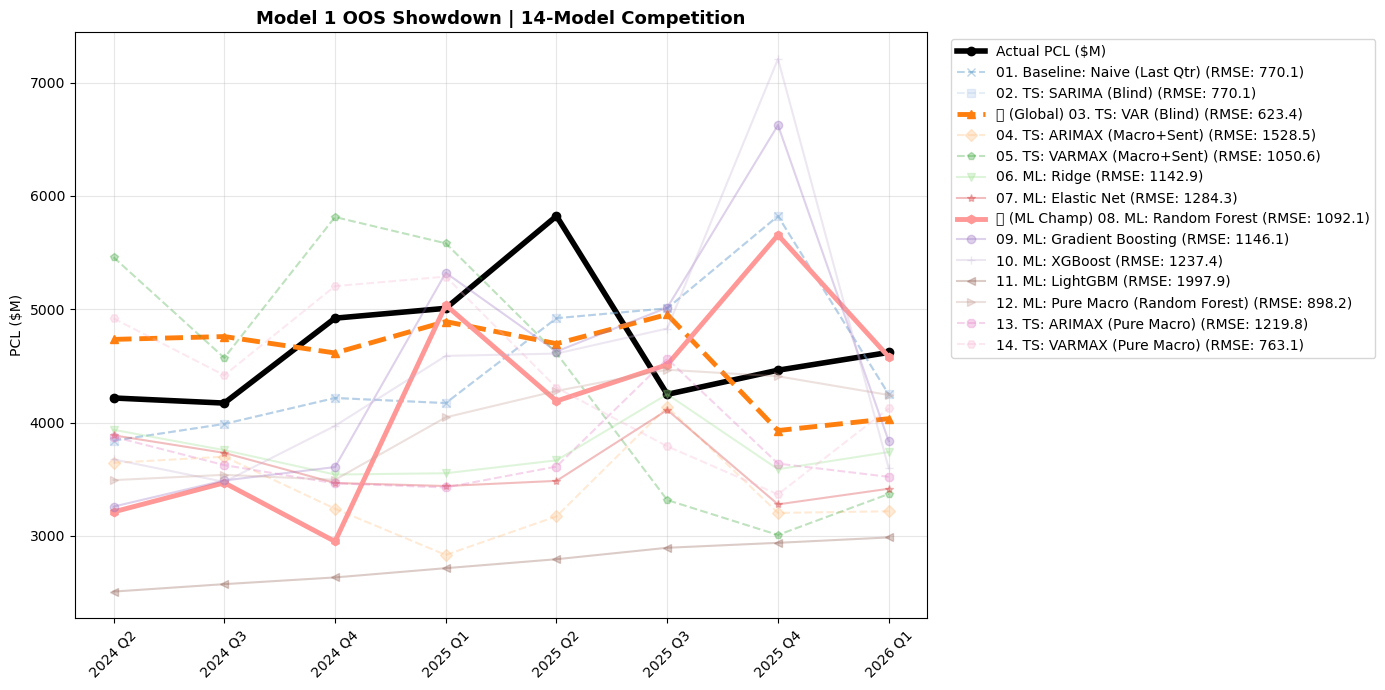

In [16]:
# ==============================================================================
# [CELL 2&3] MODEL 1 - ELASTIC NET SELECTION & 14-MODEL SHOWDOWN
# ==============================================================================
print(f"\n>>> [Cell 2&3] Executing Model 1 Pipeline (14-Model Showdown)...\n")

train_valid_df1 = model1_df.dropna(subset=["PCL_t+1"]).copy()

# 🎯 PROCESS 1: ELASTIC NET FEATURE SELECTION
tscv_fs = TimeSeriesSplit(n_splits=3)
X_cand_sc1 = StandardScaler().fit_transform(train_valid_df1[candidate_features_m1])
y_full1 = train_valid_df1["PCL_t+1"].values

elastic_fs1 = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0], cv=tscv_fs, random_state=42).fit(X_cand_sc1, y_full1)

selected_features_m1 = []
print("="*85)
print(f"🔍 PROCESS 1: MODEL 1 ELASTIC NET FEATURE SELECTION")
print("="*85)
for feat, coef in zip(candidate_features_m1, elastic_fs1.coef_):
    status = "✅ KEPT" if abs(coef) > 1e-4 else "❌ PRUNED"
    if abs(coef) > 1e-4: selected_features_m1.append(feat)
    print(f"  {status:10s} : {feat:35s} (Weight: {coef:>8.2f})")

if len(selected_features_m1) <= 1: 
    print("\n⚠️ Fallback: Forcing features for Dashboard compatibility.")
    selected_features_m1 = ["PCL_t", "Fcst_GDP_YoY_for_t+1", "Sent_BART_t"]

exog_m1 = [f for f in selected_features_m1 if f != "PCL_t"]
if not exog_m1: exog_m1 = ["Fcst_GDP_YoY_for_t+1"]

pure_macro_m1 = ["PCL_t", "Fcst_GDP_YoY_for_t+1", "Fcst_Unemp_Q_for_t+1", "Fcst_BoC_for_t+1"]
pure_avail1 = [f for f in pure_macro_m1 if f in train_valid_df1.columns]
pure_exog_m1 = [f for f in pure_avail1 if f != "PCL_t"]

# 🎯 PROCESS 2: 14-MODEL OOS BACKTEST
tscv = TimeSeriesSplit(n_splits=3)
ml_models_dict = {
    "06. ML: Ridge": RidgeCV(alphas=np.logspace(-2, 4, 50), cv=tscv),
    "07. ML: Elastic Net": ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], cv=tscv),
    "08. ML: Random Forest": RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    "09. ML: Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=2, random_state=42)
}
if HAS_XGB: ml_models_dict["10. ML: XGBoost"] = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)
if HAS_LGBM: ml_models_dict["11. ML: LightGBM"] = LGBMRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42, verbose=-1)

h_test = 8  
test_indices = list(range(len(train_valid_df1) - h_test, len(train_valid_df1)))
prediction_records1 = []

for t in test_indices:
    if t < 12: continue
    train_df, test_row = train_valid_df1.iloc[:t], train_valid_df1.iloc[t:t+1]
    y_tr_abs, y_actual = train_df["PCL_t+1"], float(test_row["PCL_t+1"].iloc[0])
    
    # 🌟 修复日期推移：准确计算 t+1 的时间戳
    pred_date = test_row.index[0] + pd.offsets.QuarterEnd()
    yr, qtr = pred_date.year, f"Q{pred_date.quarter}"
    
    def eval_mod(m_name, p_val): prediction_records1.append({'Time': pred_date, 'Year': yr, 'Quarter': qtr, 'Model': m_name, 'Predicted ($M)': float(np.squeeze(p_val)), 'Actual ($M)': y_actual})
    
    eval_mod("01. Baseline: Naive (Last Qtr)", train_df["PCL_t"].iloc[-1])
    try:
        if HAS_PMDARIMA: eval_mod("02. TS: SARIMA (Blind)", auto_arima(y_tr_abs, seasonal=False, suppress_warnings=True).predict(n_periods=1)[0])
        else: eval_mod("02. TS: SARIMA (Blind)", ARIMA(y_tr_abs.values, order=(1,0,0)).fit().forecast(steps=1)[0])
    except: eval_mod("02. TS: SARIMA (Blind)", train_df["PCL_t"].iloc[-1])
        
    try: eval_mod("03. TS: VAR (Blind)", VAR(train_df[["PCL_t+1"] + features_ts_hist]).fit(maxlags=1).forecast(train_df[["PCL_t+1"] + features_ts_hist].values[-1:], steps=1)[0, 0])
    except: eval_mod("03. TS: VAR (Blind)", train_df["PCL_t"].iloc[-1])

    try: eval_mod("04. TS: ARIMAX (Macro+Sent)", ARIMA(y_tr_abs.values, exog=train_df[exog_m1].values, order=(1,0,0)).fit().forecast(steps=1, exog=test_row[exog_m1].values)[0])
    except: eval_mod("04. TS: ARIMAX (Macro+Sent)", train_df["PCL_t"].iloc[-1])

    try: eval_mod("05. TS: VARMAX (Macro+Sent)", VARMAX(train_df[["PCL_t+1"] + features_ts_hist], exog=train_df[exog_m1], order=(1,0)).fit(disp=False).forecast(steps=1, exog=test_row[exog_m1]).iloc[0, 0])
    except: eval_mod("05. TS: VARMAX (Macro+Sent)", train_df["PCL_t"].iloc[-1])

    sc = StandardScaler()
    X_tr_sc, X_te_sc = sc.fit_transform(train_df[selected_features_m1]), sc.transform(test_row[selected_features_m1])
    for m_name, model in ml_models_dict.items():
        eval_mod(m_name, model.fit(X_tr_sc, y_tr_abs).predict(X_te_sc)[0])

# 🌟 STEP 2.5: FIND BEST ML MODEL, THEN RUN IDENTICAL PURE MACRO ABLATION
temp_df = pd.DataFrame(prediction_records1)
metrics_temp = []
for model_name, grp in temp_df.groupby("Model"):
    valid = grp.dropna()
    if len(valid) > 0: metrics_temp.append({"Model": model_name, "MAPE": np.mean(np.abs((valid["Actual ($M)"] - valid["Predicted ($M)"]) / np.abs(valid["Actual ($M)"])))})

best_ml_m1 = pd.DataFrame(metrics_temp).sort_values("MAPE").query("Model.str.contains('ML:')")["Model"].iloc[0]
best_ml_algo = best_ml_m1.split(": ")[1]
pure_model_name1 = f"12. ML: Pure Macro ({best_ml_algo})"

champ_instance1 = sklearn.base.clone(ml_models_dict[best_ml_m1])
for t in test_indices:
    if t < 12: continue
    train_df, test_row = train_valid_df1.iloc[:t], train_valid_df1.iloc[t:t+1]
    y_tr_abs, y_actual = train_df["PCL_t+1"], float(test_row["PCL_t+1"].iloc[0])
    pred_date = test_row.index[0] + pd.offsets.QuarterEnd()
    yr, qtr = pred_date.year, f"Q{pred_date.quarter}"
    
    # 12. ML Pure Macro (Homogeneous Ablation)
    sc_pure = StandardScaler()
    X_tr_pure, X_te_pure = sc_pure.fit_transform(train_df[pure_avail1]), sc_pure.transform(test_row[pure_avail1])
    try: pred = champ_instance1.fit(X_tr_pure, y_tr_abs).predict(X_te_pure)[0]
    except: pred = train_df["PCL_t"].iloc[-1]
    prediction_records1.append({'Time': pred_date, 'Year': yr, 'Quarter': qtr, 'Model': pure_model_name1, 'Predicted ($M)': float(np.squeeze(pred)), 'Actual ($M)': y_actual})
    
    # 13. TS ARIMAX Pure Macro
    try: prediction_records1.append({'Time': pred_date, 'Year': yr, 'Quarter': qtr, 'Model': "13. TS: ARIMAX (Pure Macro)", 'Predicted ($M)': float(np.squeeze(ARIMA(y_tr_abs.values, exog=train_df[pure_exog_m1].values, order=(1,0,0)).fit().forecast(steps=1, exog=test_row[pure_exog_m1].values)[0])), 'Actual ($M)': y_actual})
    except: prediction_records1.append({'Time': pred_date, 'Year': yr, 'Quarter': qtr, 'Model': "13. TS: ARIMAX (Pure Macro)", 'Predicted ($M)': float(train_df["PCL_t"].iloc[-1]), 'Actual ($M)': y_actual})

    # 14. TS VARMAX Pure Macro
    try: prediction_records1.append({'Time': pred_date, 'Year': yr, 'Quarter': qtr, 'Model': "14. TS: VARMAX (Pure Macro)", 'Predicted ($M)': float(np.squeeze(VARMAX(train_df[["PCL_t+1"] + features_ts_hist], exog=train_df[pure_exog_m1], order=(1,0)).fit(disp=False).forecast(steps=1, exog=test_row[pure_exog_m1]).iloc[0, 0])), 'Actual ($M)': y_actual})
    except: prediction_records1.append({'Time': pred_date, 'Year': yr, 'Quarter': qtr, 'Model': "14. TS: VARMAX (Pure Macro)", 'Predicted ($M)': float(train_df["PCL_t"].iloc[-1]), 'Actual ($M)': y_actual})

# Final Metrics Compilation
results_df1 = pd.DataFrame(prediction_records1).sort_values("Time")
metrics_list1 = []
for model_name, grp in results_df1.groupby("Model"):
    valid = grp.dropna(subset=["Predicted ($M)", "Actual ($M)"])
    if len(valid) > 0:
        y_a, y_p = valid["Actual ($M)"].values.astype(float), valid["Predicted ($M)"].values.astype(float)
        metrics_list1.append({"Model": model_name, "OOS R2": r2_score(y_a, y_p), "OOS MAPE": float(np.mean(np.abs((y_a - y_p) / np.abs(y_a)))) * 100, "OOS RMSE": float(np.sqrt(np.mean((y_a - y_p)**2)))})

final_table1 = pd.DataFrame(metrics_list1).sort_values(by="OOS MAPE").reset_index(drop=True)

# 🌟 核心逻辑：给 14 个模型加上直观的分组标签
def categorize_model(m_name):
    if "Blind" in m_name or "Naive" in m_name: return "🙈 1. Blind Baselines (No Inputs)"
    elif "Pure Macro" in m_name: return "📊 2. Pure Macro (Without Sentiment)"
    else: return "🚀 3. Macro + Sentiment (Full Features)"

final_table1["Category"] = final_table1["Model"].apply(categorize_model)
global_best_m1 = final_table1.iloc[0]["Model"]
is_ts_winner = "TS:" in global_best_m1 or "Baseline" in global_best_m1

# IN-SAMPLE R2 Function
def get_is_r2(mod_name, feat_list):
    X_full = StandardScaler().fit_transform(train_valid_df1[feat_list])
    m = sklearn.base.clone(ml_models_dict[best_ml_m1]) if "Pure Macro" in mod_name else sklearn.base.clone(ml_models_dict[mod_name])
    return r2_score(y_full1, m.fit(X_full, y_full1).predict(X_full))

is_r2_ml1 = get_is_r2(best_ml_m1, selected_features_m1)
is_r2_pure1 = get_is_r2(pure_model_name1, pure_avail1)

# 🎯 PROCESS 3: ACADEMIC TABLES (Categorized Multi-Index Scorecard)
print("\n" + "="*85)
print("🎯 STEP 1: MODEL 1 SCORECARD (Categorized by Scenario Utility)")
print("="*85)
scorecard_display1 = final_table1.sort_values(by=["Category", "OOS MAPE"]).set_index(["Category", "Model"])
display(scorecard_display1.style.format({"OOS R2": "{:.4f}", "OOS MAPE": "{:.2f}%", "OOS RMSE": "{:.1f}"}).set_properties(**{'text-align': 'center', 'border': '1px solid black'}).background_gradient(subset=['OOS MAPE'], cmap='Blues'))

print("\n" + "="*85)
print(f"⚖️ STEP 2: TRADE-OFF & ABLATION ANALYSIS")
print("="*85)

ml_stats1 = final_table1[final_table1["Model"] == best_ml_m1].iloc[0]
pure_stats1 = final_table1[final_table1["Model"] == pure_model_name1].iloc[0]
naive_stats1 = final_table1[final_table1["Model"] == "01. Baseline: Naive (Last Qtr)"].iloc[0]

table_1 = pd.DataFrame({
    "Metric": ["In-Sample R² (Fit)", "OOS R² (Testing)", "OOS MAPE (%)", "OOS RMSE ($M)"],
    f"🏆 Sentiment ML ({best_ml_algo})": [is_r2_ml1, ml_stats1["OOS R2"], ml_stats1["OOS MAPE"], ml_stats1["OOS RMSE"]],
    f"📉 Pure Macro ({best_ml_algo})": [is_r2_pure1, pure_stats1["OOS R2"], pure_stats1["OOS MAPE"], pure_stats1["OOS RMSE"]],
    "📏 Naive Baseline": [r2_score(y_full1, train_valid_df1["PCL_t"]), naive_stats1["OOS R2"], naive_stats1["OOS MAPE"], naive_stats1["OOS RMSE"]]
})
table_1["Sentiment Value Add"] = table_1[f"🏆 Sentiment ML ({best_ml_algo})"] - table_1[f"📉 Pure Macro ({best_ml_algo})"]
display(table_1.style.format({f"🏆 Sentiment ML ({best_ml_algo})": "{:.4f}", f"📉 Pure Macro ({best_ml_algo})": "{:.4f}", "📏 Naive Baseline": "{:.4f}", "Sentiment Value Add": "{:+.4f}"}, na_rep="-").set_properties(**{'text-align': 'center', 'border': '1px solid black'}).hide(axis="index"))

print("\n" + "="*85)
print(f"📄 STEP 3: DETAILED OOS PREDICTIONS (ALL 14 MODELS CROSS-COMPARISON)")
print("="*85)
pivot_pred1 = results_df1.pivot_table(index=["Time", "Year", "Quarter", "Actual ($M)"], columns="Model", values="Predicted ($M)").reset_index()
pivot_pred1 = pivot_pred1.drop(columns=['Time'])
format_dict1 = {"Actual ($M)": "{:,.1f}"}
for col in pivot_pred1.columns[3:]: format_dict1[col] = "{:,.1f}"
display(pivot_pred1.style.format(format_dict1).set_properties(**{'text-align': 'center', 'border': '1px solid #ddd'}).hide(axis="index").background_gradient(subset=["Actual ($M)"], cmap='Greys'))

plt.close('all'); fig_sd, ax_sd = plt.subplots(figsize=(14, 7))
detail_df = results_df1[results_df1["Model"] == global_best_m1].drop_duplicates(subset=["Time"]).sort_values("Time")
time_labels = [f"{y} {q}" for y, q in zip(detail_df["Year"], detail_df["Quarter"])]
x_ticks_sd = np.arange(len(time_labels))
ax_sd.plot(x_ticks_sd, detail_df["Actual ($M)"].values, 'k-o', label="Actual PCL ($M)", linewidth=4.0)

colors, markers = sns.color_palette("tab20", 14), ['x', 's', '^', 'D', 'p', 'v', '*', 'h', 'o', '+', '<', '>', '8', 'H']
for i, m_name in enumerate(sorted(final_table1["Model"])):
    m_data = results_df1[results_df1["Model"] == m_name].sort_values("Time")
    is_main = (m_name == global_best_m1) or (m_name == best_ml_m1)
    lw = 3.5 if is_main else 1.5
    lbl_prefix = "🏆 (Global) " if m_name == global_best_m1 else ("🚀 (ML Champ) " if m_name == best_ml_m1 else "")
    ax_sd.plot(x_ticks_sd, m_data["Predicted ($M)"].values, linestyle='--' if 'Baseline' in m_name or 'TS:' in m_name else '-', marker=markers[i%len(markers)], color=colors[i%len(colors)], label=f"{lbl_prefix}{m_name} (RMSE: {final_table1[final_table1['Model'] == m_name]['OOS RMSE'].iloc[0]:.1f})", linewidth=lw, alpha=1.0 if is_main else 0.3)

ax_sd.set_xticks(x_ticks_sd); ax_sd.set_xticklabels(time_labels, rotation=45)
ax_sd.set_title(f"Model 1 OOS Showdown | 14-Model Competition", fontweight="bold", fontsize=13); ax_sd.set_ylabel("PCL ($M)"); ax_sd.grid(True, alpha=0.3); ax_sd.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)
plt.tight_layout(); display(fig_sd)


>>> [Cell 3.5] Deep Dive into Model Explainability...



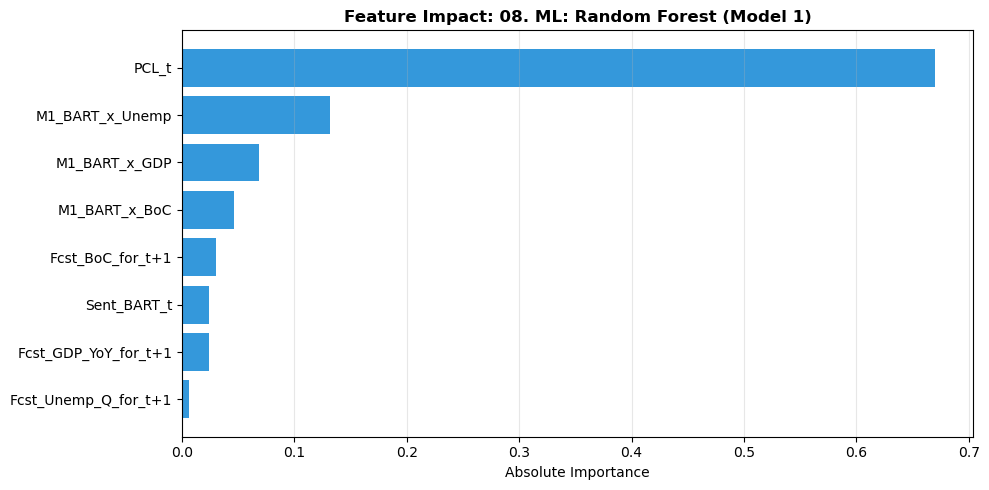


📊 TIME SERIES CHAMPION PARAMETERS (03. TS: VAR (Blind))
   Note: TS models rely on lags (AR) and moving averages (MA).
   The following summary provides academic P-values and coefficients.
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 26, Mar, 2026
Time:                     15:51:34
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    16.4149
Nobs:                     32.0000    HQIC:                   16.0475
Log likelihood:          -378.063    FPE:                7.79677e+06
AIC:                      15.8653    Det(Omega_mle):     5.47592e+06
--------------------------------------------------------------------
Results for equation PCL_t+1
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const             

In [17]:
# ==============================================================================
# [CELL 3.5] MODEL 1 - EXPLAINABILITY (ML FEATURES & TS STATISTICAL SUMMARY)
# ==============================================================================
print(f"\n>>> [Cell 3.5] Deep Dive into Model Explainability...\n")

sc_full1 = StandardScaler()
X_full_sc1 = sc_full1.fit_transform(train_valid_df1[selected_features_m1])
y_full_abs1 = train_valid_df1["PCL_t+1"].values

champ_mod_expl1 = sklearn.base.clone(ml_models_dict[best_ml_m1])
champ_mod_expl1.fit(X_full_sc1, y_full_abs1)

is_tree1 = hasattr(champ_mod_expl1, 'feature_importances_')
importances1 = champ_mod_expl1.feature_importances_ if is_tree1 else champ_mod_expl1.coef_
label_col1 = 'Importance (Tree)' if is_tree1 else 'Coefficient (Linear)'

df_imp1 = pd.DataFrame({'Feature': selected_features_m1, label_col1: importances1})
df_imp1['Abs_Value'] = np.abs(df_imp1[label_col1])
df_imp1 = df_imp1.sort_values(by='Abs_Value', ascending=True)

plt.figure(figsize=(10, 5))
colors1 = '#3498db' if is_tree1 else ['#2ecc71' if val > 0 else '#e74c3c' for val in df_imp1[label_col1]]
plt.barh(df_imp1['Feature'], df_imp1[label_col1], color=colors1)
plt.title(f"Feature Impact: {best_ml_m1} (Model 1)", fontweight='bold')
plt.xlabel("Absolute Importance" if is_tree1 else "Coefficient Value (Red=Negative, Green=Positive)")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

if is_ts_winner:
    print("\n" + "="*85)
    print(f"📊 TIME SERIES CHAMPION PARAMETERS ({global_best_m1})")
    print("   Note: TS models rely on lags (AR) and moving averages (MA).")
    print("   The following summary provides academic P-values and coefficients.")
    print("="*85)
    try:
        cur_exog1 = pure_exog_m1 if "Pure Macro" in global_best_m1 else exog_m1
        if "VARMAX" in global_best_m1:
            print(VARMAX(train_valid_df1[["PCL_t+1"] + features_ts_hist], exog=train_valid_df1[cur_exog1], order=(1,0)).fit(disp=False).summary())
        elif "VAR" in global_best_m1:
            print(VAR(train_valid_df1[["PCL_t+1"] + features_ts_hist]).fit(maxlags=1).summary())
        elif "ARIMAX" in global_best_m1:
            print(ARIMA(y_full_abs1, exog=train_valid_df1[cur_exog1].values, order=(1,0,0)).fit().summary())
        elif "SARIMA" in global_best_m1:
            print(ARIMA(y_full_abs1, order=(1,0,0)).fit().summary())
    except Exception as e:
        print("Summary generation not available for this specific TS configuration.")

>>> [Cell 4] Deploying Dual-Champions for Model 1...
    🚀 Macro-Sensitive Engine (Base)      : 08. ML: Random Forest
    📏 Global Best Engine (Blind Base)    : 03. TS: VAR (Blind)


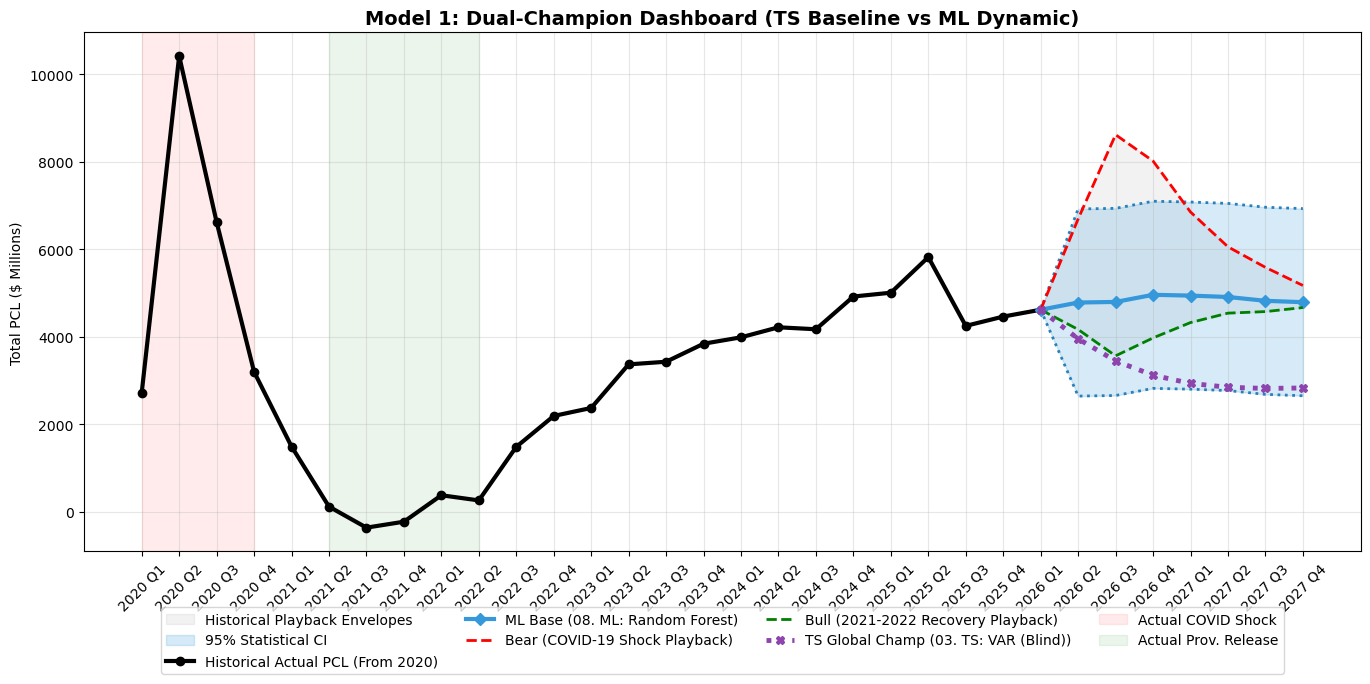

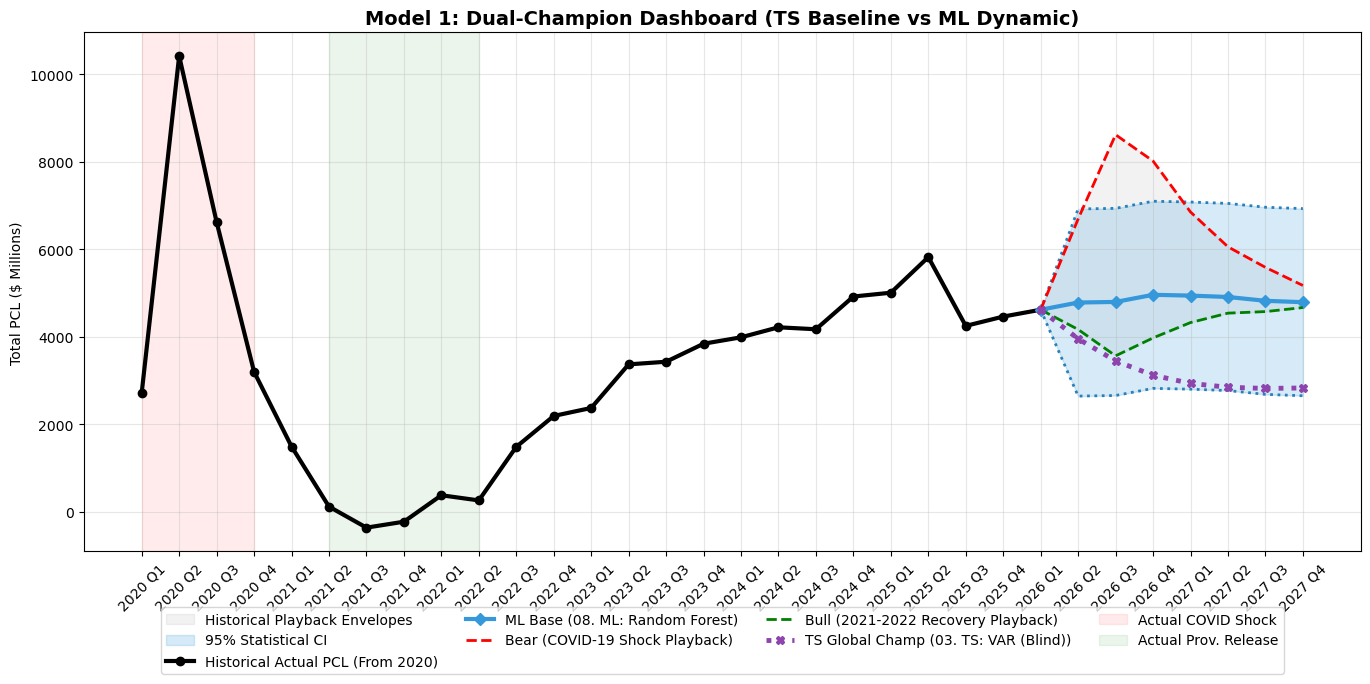

In [18]:
# ==============================================================================
# [CELL 4] MODEL 1 - DUAL-CHAMPION DASHBOARD (EXPERT OVERLAY + TS VS ML)
# ==============================================================================
import os

is_ts_winner1 = global_best_m1 != best_ml_m1

print(f">>> [Cell 4] Deploying Dual-Champions for Model 1...")
print(f"    🚀 Macro-Sensitive Engine (Base)      : {best_ml_m1}")
if is_ts_winner1: print(f"    📏 Global Best Engine (Blind Base)    : {global_best_m1}")

sc_final1 = StandardScaler()
X_final_sc1 = sc_final1.fit_transform(train_valid_df1[selected_features_m1])
y_final_abs1 = train_valid_df1["PCL_t+1"]

champion_model1 = sklearn.base.clone(ml_models_dict[best_ml_m1])
champion_model1.fit(X_final_sc1, y_final_abs1)
best_rmse1 = final_table1[final_table1["Model"] == best_ml_m1]["OOS RMSE"].iloc[0]

file_sheet1 = "Complete_UC2_Forecast_Data.xlsx"
raw_fcst_df = pd.read_excel(file_sheet1, sheet_name="Sheet1")
raw_fcst_df["Year"] = raw_fcst_df["Year"].fillna(0).astype(int)

agg_fcst_funcs = {"GDP YoY Forecast": "mean", "Unemployment Rate YoY QUARTER": "mean", "Overnight Rate": "mean"}
agg_fcst = raw_fcst_df.groupby(["Year", "Quarter"], as_index=False).agg(agg_fcst_funcs).sort_values(["Year", "Quarter"]).reset_index(drop=True)

f_idx = pd.DatetimeIndex(agg_fcst["Year"].astype(str) + "-" + agg_fcst["Quarter"].map({"Q1": "03-31", "Q2": "06-30", "Q3": "09-30", "Q4": "12-31"}))
fc_hor = len(f_idx)

agg_hist_nlp = model1_df["Sent_BART_t"].dropna().values 
try: future_nlp_base = auto_arima(agg_hist_nlp, seasonal=False, suppress_warnings=True).predict(n_periods=fc_hor) if HAS_PMDARIMA else ARIMA(agg_hist_nlp, order=(1,0,0)).fit().forecast(steps=fc_hor)
except: future_nlp_base = np.repeat(agg_hist_nlp[-1], fc_hor)

future_pool_base1 = pd.DataFrame(index=range(fc_hor))
future_pool_base1["Fcst_GDP_YoY_for_t+1"] = agg_fcst["GDP YoY Forecast"].values
future_pool_base1["Fcst_Unemp_Q_for_t+1"] = agg_fcst["Unemployment Rate YoY QUARTER"].values
future_pool_base1["Fcst_BoC_for_t+1"] = agg_fcst["Overnight Rate"].values
future_pool_base1["Sent_BART_t"] = future_nlp_base
future_pool_base1["M1_BART_x_GDP"] = future_nlp_base * agg_fcst["GDP YoY Forecast"].values
future_pool_base1["M1_BART_x_Unemp"] = future_nlp_base * agg_fcst["Unemployment Rate YoY QUARTER"].values
future_pool_base1["M1_BART_x_BoC"] = future_nlp_base * agg_fcst["Overnight Rate"].values
future_pool_base1["PCL_t"] = np.nan 

pcl_base_ml1 = []
last_known_pcl = model1_df["PCL_t"].dropna().iloc[-1]
curr_pcl = last_known_pcl

for i in range(fc_hor):
    future_pool_base1.loc[i, "PCL_t"] = curr_pcl
    pred = champion_model1.predict(sc_final1.transform(future_pool_base1.iloc[i:i+1][selected_features_m1]))[0]
    pcl_base_ml1.append(pred)
    curr_pcl = pred

pcl_base_ml1 = np.array(pcl_base_ml1)

pre_covid = model1_df.loc["2019-12-31", "PCL_t"] if "2019-12-31" in model1_df.index else 1500
covid_peak = model1_df.loc["2020-09-30", "PCL_t"] if "2020-09-30" in model1_df.index else 6000
covid_shock_magnitude = max(0, covid_peak - pre_covid)

pre_recovery = model1_df.loc["2021-03-31", "PCL_t"] if "2021-03-31" in model1_df.index else 1500
recovery_trough = model1_df.loc["2022-06-30", "PCL_t"] if "2022-06-30" in model1_df.index else 0
recovery_magnitude = max(0, pre_recovery - recovery_trough)

playback_curve = np.array([0.5, 1.0, 0.8, 0.5, 0.3, 0.2, 0.1, 0.0])[:fc_hor]
pcl_bear_ml1 = pcl_base_ml1 + (covid_shock_magnitude * playback_curve)
pcl_bull_ml1 = pcl_base_ml1 - (recovery_magnitude * playback_curve)

pcl_upper_ml1 = pcl_base_ml1 + 1.96 * best_rmse1
pcl_lower_ml1 = pcl_base_ml1 - 1.96 * best_rmse1

pcl_base_ts1 = []
if is_ts_winner1:
    cur_exog1 = pure_exog_m1 if "Pure Macro" in global_best_m1 else exog_m1
    if "VARMAX" in global_best_m1:
        try: vmax = VARMAX(train_valid_df1[["PCL_t+1"] + features_ts_hist], exog=train_valid_df1[cur_exog1], order=(1,0)).fit(disp=False); pcl_base_ts1 = vmax.forecast(steps=fc_hor, exog=future_pool_base1[cur_exog1]).iloc[:, 0].values
        except: pcl_base_ts1 = np.repeat(last_known_pcl, fc_hor)
    elif "VAR" in global_best_m1:
        try: var_mod = VAR(train_valid_df1[["PCL_t+1"] + features_ts_hist]).fit(maxlags=1); pcl_base_ts1 = var_mod.forecast(train_valid_df1[["PCL_t+1"] + features_ts_hist].values[-1:], steps=fc_hor)[:, 0]
        except: pcl_base_ts1 = np.repeat(last_known_pcl, fc_hor)
    elif "ARIMAX" in global_best_m1:
        try: arimax_m = ARIMA(train_valid_df1["PCL_t+1"].values, exog=train_valid_df1[cur_exog1].values, order=(1,0,0)).fit(); pcl_base_ts1 = arimax_m.forecast(steps=fc_hor, exog=future_pool_base1[cur_exog1].values)
        except: pcl_base_ts1 = np.repeat(last_known_pcl, fc_hor)
    elif "SARIMA" in global_best_m1:
        try: pcl_base_ts1 = ARIMA(train_valid_df1["PCL_t+1"].values, order=(1,0,0)).fit().forecast(steps=fc_hor)
        except: pcl_base_ts1 = np.repeat(last_known_pcl, fc_hor)
    else: pcl_base_ts1 = np.repeat(last_known_pcl, fc_hor)

hist_dates = model1_df[model1_df.index >= "2020-01-01"].index
all_dates = list(hist_dates) + list(f_idx)
x_ticks = np.arange(len(all_dates))
x_labels = [f"{d.year} Q{d.quarter}" for d in all_dates]

y_hist = list(model1_df.loc[hist_dates, "PCL_t"].values) + [np.nan] * fc_hor
pad_length = len(hist_dates) - 1

plt.close('all'); fig_fan, ax_fan = plt.subplots(figsize=(14, 7))

ax_fan.fill_between(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_bear_ml1), [np.nan]*pad_length+[last_known_pcl]+list(pcl_bull_ml1), alpha=0.10, color='gray', label="Historical Playback Envelopes")
ax_fan.fill_between(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_lower_ml1), [np.nan]*pad_length+[last_known_pcl]+list(pcl_upper_ml1), alpha=0.20, color='#3498db', label="95% Statistical CI")

ax_fan.plot(x_ticks, y_hist, 'k-o', label="Historical Actual PCL (From 2020)", linewidth=3.0)
ax_fan.plot(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_upper_ml1), color='#2980b9', linestyle=':', linewidth=2.0)
ax_fan.plot(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_lower_ml1), color='#2980b9', linestyle=':', linewidth=2.0)

ax_fan.plot(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_base_ml1), color='#3498db', marker='D', label=f"ML Base ({best_ml_m1})", linewidth=3.0)
ax_fan.plot(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_bear_ml1), 'r--', label="Bear (COVID-19 Shock Playback)", linewidth=2.0)
ax_fan.plot(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_bull_ml1), 'g--', label="Bull (2021-2022 Recovery Playback)", linewidth=2.0)

if is_ts_winner1:
    ax_fan.plot(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_base_ts1), color='#8e44ad', marker='X', linestyle=':', label=f"TS Global Champ ({global_best_m1})", linewidth=3.5)

try:
    c_start, c_end = list(hist_dates).index(pd.to_datetime("2020-03-31")), list(hist_dates).index(pd.to_datetime("2020-12-31"))
    ax_fan.axvspan(c_start, c_end, color='red', alpha=0.08, label="Actual COVID Shock")
    r_start, r_end = list(hist_dates).index(pd.to_datetime("2021-06-30")), list(hist_dates).index(pd.to_datetime("2022-06-30"))
    ax_fan.axvspan(r_start, r_end, color='green', alpha=0.08, label="Actual Prov. Release")
except: pass

ax_fan.set_xticks(x_ticks); ax_fan.set_xticklabels(x_labels, rotation=45)
ax_fan.set_title(f"Model 1: Dual-Champion Dashboard (TS Baseline vs ML Dynamic)", fontweight="bold", fontsize=14)
ax_fan.set_ylabel("Total PCL ($ Millions)"); ax_fan.grid(True, alpha=0.3); ax_fan.legend(loc="lower center", ncol=4 if is_ts_winner1 else 3, bbox_to_anchor=(0.5, -0.25))
plt.tight_layout(); display(fig_fan)

ui_out1 = widgets.Output()
q_str_list = [f"{d.year} Q{d.quarter}" for d in f_idx]
drop1 = widgets.Dropdown(options=q_str_list, description='Future Quarter:')

def update_ui1(change):
    selected_str = change.new if hasattr(change, 'new') else change
    idx_pos = q_str_list.index(selected_str)
    
    with ui_out1:
        clear_output(wait=True)
        feature_rows_html = ""
        for feat in selected_features_m1:
            val = future_pool_base1.loc[idx_pos, feat]
            feature_rows_html += f"<tr style='border-bottom:1px solid #eee;'><td><b>{feat}</b></td><td style='text-align:right;'>{val:,.2f}</td></tr>"

        ts_box_html = ""
        if is_ts_winner1:
            ts_box_html = f"""
            <div style="background:#F4ECF7; padding:10px; border-radius:5px; margin: 15px 0 5px 0; border-left: 4px solid #8e44ad;">
                <b style="color:#2C3E50;">TS Global Champ ({global_best_m1}):</b> <span style="float:right; font-weight:bold; font-size:1.1em; color:#8e44ad;">${pcl_base_ts1[idx_pos]:,.0f}</span>
                <div style="clear:both;"></div>
                <p style="font-size:0.8em; color:#7F8C8D; margin:4px 0 0 0; text-align:right;">*Control Model Forecast</p>
            </div>
            """

        html_str = f"""
        <div style="font-family:sans-serif; border:2px solid #2C3E50; border-radius:12px; padding:15px; max-width:950px;">
            <h2 style="color:#2C3E50; text-align:center; border-bottom:2px solid #BDC3C7;">🏦 Model 1 Direct PCL Dashboard<br><span style="font-size:16px;">Quarter: {selected_str}</span></h2>
            <div style="display:flex; justify-content:space-between;">
                <div style="width:48%;">
                    <h3 style="color:#2C3E50;">🎯 Final Projections ($M)</h3>
                    
                    <p style="color:#c0392b; margin:4px 0;">🔴 <b>Bear (COVID Playback):</b> <span style="float:right; font-weight:bold;">${pcl_bear_ml1[idx_pos]:,.0f}</span></p>
                    <p style="color:#2980b9; margin:4px 0; font-size: 0.9em;">🔺 <b>95% CI Upper Bound:</b> <span style="float:right;">${pcl_upper_ml1[idx_pos]:,.0f}</span></p>
                    
                    <div style="background:#D6EAF8; padding:10px; border-radius:5px; margin: 10px 0; border-left: 4px solid #3498db;">
                        <b style="color:#2C3E50;">ML Base ({best_ml_m1}):</b> <span style="float:right; font-weight:bold; font-size:1.1em; color:#2980b9;">${pcl_base_ml1[idx_pos]:,.0f}</span>
                        <div style="clear:both;"></div>
                    </div>
                    
                    <p style="color:#2980b9; margin:4px 0; font-size: 0.9em;">🔻 <b>95% CI Lower Bound:</b> <span style="float:right;">${pcl_lower_ml1[idx_pos]:,.0f}</span></p>
                    <p style="color:#27ae60; margin:4px 0;">🟢 <b>Bull (Recovery Playback):</b> <span style="float:right; font-weight:bold;">${pcl_bull_ml1[idx_pos]:,.0f}</span></p>
                    
                    {ts_box_html}
                </div>
                
                <div style="width:48%; border-left:2px dashed #BDC3C7; padding-left:15px;">
                    <h3 style="color:#2980b9;">📊 Features Driving the Forecast</h3>
                    <table style="width:100%; font-size:12px; border-collapse:collapse;">
                        <tr style="color:#7F8C8D; border-bottom:1px solid #ccc;"><th align="left">Feature</th><th style="text-align:right;">Assumed Value</th></tr>
                        {feature_rows_html}
                    </table>
                </div>
            </div>
        </div>
        """
        display(HTML(html_str))

drop1.observe(update_ui1, names='value')
display(widgets.VBox([drop1, ui_out1]))
update_ui1(drop1.value)

# Model 2 (Refreshed / 1-Month Data)

In [19]:
# ==============================================================================
# [CELL 5] MODEL 2 (REFRESHED 1-MONTH) - ABSOLUTE MODELING SETUP & KNN IMPUTATION
# ==============================================================================
print("\n>>> [Cell 5] Building feature pool for Model 2 (Refreshed 1-Month Prior Forecasts)...")

file_hist = "Complete_UC2_Forecast_Data.xlsx"
raw_df2 = pd.read_excel(file_hist, sheet_name="Forecast Data", header=1)

cols_to_clean2 = ["PCL_t+1", "PCL_t", "Sent_BART_t", "Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1", "Unemp_1_month_prior _to_t+1", "Rfsh_Fcst_BoC_1_month_prior_to_t+1", "GDP_YoY_t", "Overnight_Rate_t"]
for c in cols_to_clean2:
    if c in raw_df2.columns: raw_df2[c] = raw_df2[c].apply(clean_num)

raw_df2 = raw_df2.sort_values(by=["Bank", "Year", "Quarter"])
cols_to_fill2 = ["PCL_t", "Sent_BART_t", "Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1", "Unemp_1_month_prior _to_t+1", "Rfsh_Fcst_BoC_1_month_prior_to_t+1"]

for c in cols_to_fill2:
    if c in raw_df2.columns: 
        raw_df2[c] = raw_df2.groupby("Bank")[c].transform(lambda x: x.ffill().bfill())

agg_funcs2 = {"PCL_t+1": sum_safe, "PCL_t": sum_safe, "Sent_BART_t": "mean", "Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1": "mean", "Unemp_1_month_prior _to_t+1": "mean", "Rfsh_Fcst_BoC_1_month_prior_to_t+1": "mean", "GDP_YoY_t": "mean", "Overnight_Rate_t": "mean"}
agg_funcs2 = {k: v for k, v in agg_funcs2.items() if k in raw_df2.columns}

agg_df2 = raw_df2.groupby(["Year", "Quarter"], as_index=False).agg(agg_funcs2)
agg_df2.index = pd.DatetimeIndex(agg_df2["Year"].fillna(0).astype(int).astype(str) + "-" + agg_df2["Quarter"].map(q_map))
agg_df2 = agg_df2.sort_index().asfreq(Q_FREQ)
agg_df2 = agg_df2[agg_df2.index <= "2026-03-31"]

candidate_features_m2 = ["PCL_t", "Sent_BART_t", "Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1", "Unemp_1_month_prior _to_t+1", "Rfsh_Fcst_BoC_1_month_prior_to_t+1"]
features_ts_hist = ["GDP_YoY_t", "Overnight_Rate_t"] 
features_to_impute2 = candidate_features_m2 + features_ts_hist

knn_imputer2 = KNNImputer(n_neighbors=3, weights='distance')
agg_df2[features_to_impute2] = knn_imputer2.fit_transform(agg_df2[features_to_impute2])

agg_df2["M2_BART_x_GDP"] = agg_df2["Sent_BART_t"] * agg_df2["Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1"]
agg_df2["M2_BART_x_Unemp"] = agg_df2["Sent_BART_t"] * agg_df2["Unemp_1_month_prior _to_t+1"]
agg_df2["M2_BART_x_BoC"] = agg_df2["Sent_BART_t"] * agg_df2["Rfsh_Fcst_BoC_1_month_prior_to_t+1"]

candidate_features_m2.extend(["M2_BART_x_GDP", "M2_BART_x_Unemp", "M2_BART_x_BoC"])
model2_df = agg_df2[["PCL_t+1", "Year", "Quarter"] + candidate_features_m2 + features_ts_hist].copy()

print(f"✅ Cell 5 (Model 2) Complete! KNN Imputation applied. Actual PCL_t (2026 Q1): ${model2_df['PCL_t'].dropna().iloc[-1]:,.0f}M")


>>> [Cell 5] Building feature pool for Model 2 (Refreshed 1-Month Prior Forecasts)...
✅ Cell 5 (Model 2) Complete! KNN Imputation applied. Actual PCL_t (2026 Q1): $4,619M



>>> [Cell 6&7] Executing Model 2 Pipeline (TS vs ML vs Pure Macro)...

🔍 PROCESS 1: MODEL 2 ELASTIC NET FEATURE SELECTION
  ✅ KEPT     : PCL_t                               (Weight:  1071.83)
  ✅ KEPT     : Sent_BART_t                         (Weight:   631.83)
  ❌ PRUNED   : Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1 (Weight:    -0.00)
  ❌ PRUNED   : Unemp_1_month_prior _to_t+1         (Weight:    -0.00)
  ✅ KEPT     : Rfsh_Fcst_BoC_1_month_prior_to_t+1  (Weight:   765.66)
  ✅ KEPT     : M2_BART_x_GDP                       (Weight: -1341.74)
  ✅ KEPT     : M2_BART_x_Unemp                     (Weight:   281.32)
  ❌ PRUNED   : M2_BART_x_BoC                       (Weight:     0.00)

🎯 STEP 1: MODEL 2 SCORECARD (Categorized by Scenario Utility)



⚖️ STEP 2: TRADE-OFF & ABLATION ANALYSIS


Metric,🏆 Sentiment ML (XGBoost),📉 Pure Macro (XGBoost),📏 Naive Baseline,Sentiment Value Add
In-Sample R² (Fit),0.9931,0.9924,0.3495,+0.0007
OOS R² (Testing),-2.2574,-1.6295,-1.1770,-0.6279
OOS MAPE (%),15.9258,15.7494,14.5193,+0.1764
OOS RMSE ($M),941.9648,846.3273,770.0752,+95.6375



📄 STEP 3: DETAILED OOS PREDICTIONS (ALL 14 MODELS CROSS-COMPARISON)


Year,Quarter,Actual ($M),01. Baseline: Naive (Last Qtr),02. TS: SARIMA (Blind),03. TS: VAR (Blind),04. TS: ARIMAX (Macro+Sent),05. TS: VARMAX (Macro+Sent),06. ML: Ridge,07. ML: Elastic Net,08. ML: Random Forest,09. ML: Gradient Boosting,10. ML: XGBoost,11. ML: LightGBM,12. ML: Pure Macro (XGBoost),13. TS: ARIMAX (Pure Macro),14. TS: VARMAX (Pure Macro)
2024,Q2,"4,217.0","3,841.0","3,841.0","4,733.8","3,791.9","4,076.3","3,658.5","3,437.1","2,778.5","2,671.6","3,535.2","2,509.1","3,625.9","3,526.0","3,980.3"
2024,Q3,"4,172.0","3,988.0","3,988.0","4,758.9","3,587.6","4,083.1","3,809.8","3,479.2","3,405.7","3,674.0","3,897.1","2,574.8","3,337.3","3,371.7","4,042.4"
2024,Q4,"4,921.0","4,217.0","4,217.0","4,614.0","3,268.4","3,937.3","3,605.1","3,271.3","2,676.6","3,047.0","3,223.5","2,634.0","3,692.4","3,047.6","4,012.8"
2025,Q1,"5,008.0","4,172.0","4,172.0","4,891.1","3,560.2","4,039.5","4,121.2","3,522.7","3,537.0","4,325.6","3,835.2","2,715.6","3,994.0","3,193.1","3,986.1"
2025,Q2,"5,822.0","4,921.0","4,921.0","4,696.0","3,890.1","3,920.1","4,018.6","3,628.2","4,203.4","4,819.4","4,443.9","2,794.7","4,503.5","3,541.2","3,755.4"
2025,Q3,"4,249.0","5,008.0","5,008.0","4,953.6","4,605.6","3,726.2","4,256.4","4,038.0","4,295.1","4,568.7","4,480.4","2,895.6","4,646.9","4,411.3","3,455.8"
2025,Q4,"4,462.0","5,822.0","5,822.0","3,929.8","4,463.2","3,988.2","5,022.4","3,323.9","4,599.2","4,431.5","4,986.2","2,939.3","4,010.4","3,758.9","3,792.8"
2026,Q1,"4,619.0","4,249.0","4,249.0","4,034.4","4,311.8","3,901.2","5,529.1","4,396.6","4,396.5","4,462.8","4,347.8","2,986.8","4,405.4","3,676.2","3,693.8"


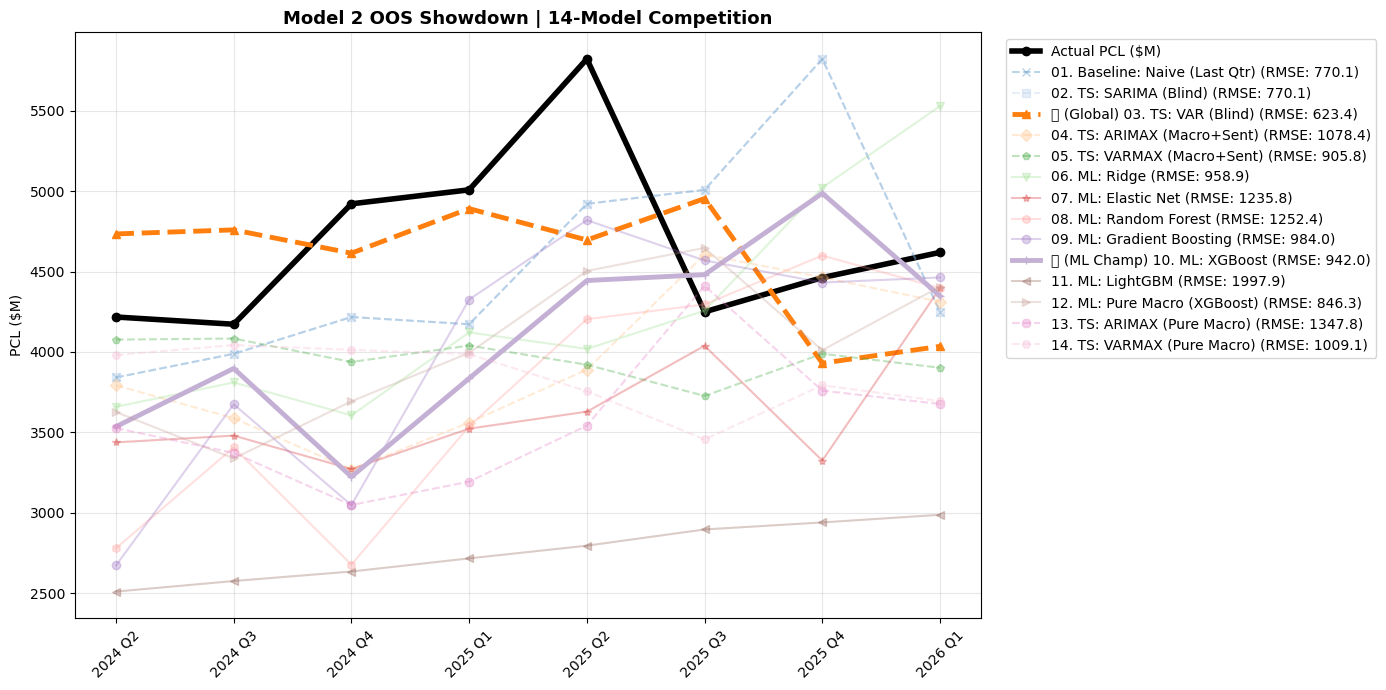

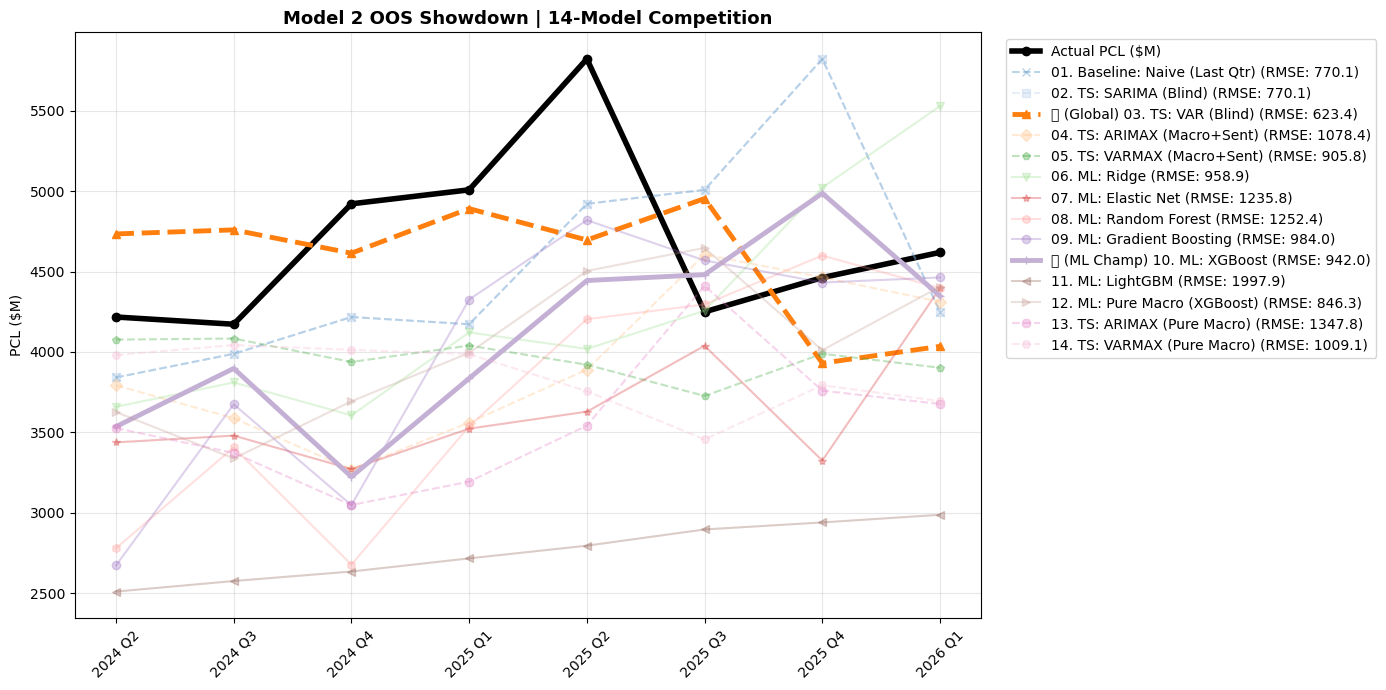

In [20]:
# ==============================================================================
# [CELL 6&7] MODEL 2 - ELASTIC NET SELECTION & 14-MODEL SHOWDOWN
# ==============================================================================
print(f"\n>>> [Cell 6&7] Executing Model 2 Pipeline (TS vs ML vs Pure Macro)...\n")

train_valid_df2 = model2_df.dropna(subset=["PCL_t+1"]).copy()

# 🎯 PROCESS 1: ELASTIC NET FEATURE SELECTION
tscv_fs2 = TimeSeriesSplit(n_splits=3)
X_cand_sc2 = StandardScaler().fit_transform(train_valid_df2[candidate_features_m2])
y_full2 = train_valid_df2["PCL_t+1"].values

elastic_fs2 = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0], cv=tscv_fs2, random_state=42).fit(X_cand_sc2, y_full2)

selected_features_m2 = []
print("="*85)
print(f"🔍 PROCESS 1: MODEL 2 ELASTIC NET FEATURE SELECTION")
print("="*85)
for feat, coef in zip(candidate_features_m2, elastic_fs2.coef_):
    status = "✅ KEPT" if abs(coef) > 1e-4 else "❌ PRUNED"
    if abs(coef) > 1e-4: selected_features_m2.append(feat)
    print(f"  {status:10s} : {feat:35s} (Weight: {coef:>8.2f})")

if len(selected_features_m2) <= 1: 
    print("\n⚠️ Fallback: Forcing features for Dashboard compatibility.")
    selected_features_m2 = ["PCL_t", "Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1", "Sent_BART_t"]

exog_m2 = [f for f in selected_features_m2 if f != "PCL_t"]
if not exog_m2: exog_m2 = ["Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1"]

pure_macro_m2 = ["PCL_t", "Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1", "Unemp_1_month_prior _to_t+1", "Rfsh_Fcst_BoC_1_month_prior_to_t+1"]
pure_avail2 = [f for f in pure_macro_m2 if f in train_valid_df2.columns]
pure_exog_m2 = [f for f in pure_avail2 if f != "PCL_t"]

# 🎯 PROCESS 2: 14-MODEL OOS BACKTEST
prediction_records2 = []
for t in test_indices:
    if t < 12: continue
    train_df, test_row = train_valid_df2.iloc[:t], train_valid_df2.iloc[t:t+1]
    y_tr_abs, y_actual = train_df["PCL_t+1"], float(test_row["PCL_t+1"].iloc[0])
    
    pred_date = test_row.index[0] + pd.offsets.QuarterEnd()
    yr, qtr = pred_date.year, f"Q{pred_date.quarter}"
    
    def eval_mod(m_name, p_val): prediction_records2.append({'Time': pred_date, 'Year': yr, 'Quarter': qtr, 'Model': m_name, 'Predicted ($M)': float(np.squeeze(p_val)), 'Actual ($M)': y_actual})
    
    eval_mod("01. Baseline: Naive (Last Qtr)", train_df["PCL_t"].iloc[-1])
    try:
        if HAS_PMDARIMA: eval_mod("02. TS: SARIMA (Blind)", auto_arima(y_tr_abs, seasonal=False, suppress_warnings=True).predict(n_periods=1)[0])
        else: eval_mod("02. TS: SARIMA (Blind)", ARIMA(y_tr_abs.values, order=(1,0,0)).fit().forecast(steps=1)[0])
    except: eval_mod("02. TS: SARIMA (Blind)", train_df["PCL_t"].iloc[-1])
        
    try: eval_mod("03. TS: VAR (Blind)", VAR(train_df[["PCL_t+1"] + features_ts_hist]).fit(maxlags=1).forecast(train_df[["PCL_t+1"] + features_ts_hist].values[-1:], steps=1)[0, 0])
    except: eval_mod("03. TS: VAR (Blind)", train_df["PCL_t"].iloc[-1])

    try: eval_mod("04. TS: ARIMAX (Macro+Sent)", ARIMA(y_tr_abs.values, exog=train_df[exog_m2].values, order=(1,0,0)).fit().forecast(steps=1, exog=test_row[exog_m2].values)[0])
    except: eval_mod("04. TS: ARIMAX (Macro+Sent)", train_df["PCL_t"].iloc[-1])

    try: eval_mod("05. TS: VARMAX (Macro+Sent)", VARMAX(train_df[["PCL_t+1"] + features_ts_hist], exog=train_df[exog_m2], order=(1,0)).fit(disp=False).forecast(steps=1, exog=test_row[exog_m2]).iloc[0, 0])
    except: eval_mod("05. TS: VARMAX (Macro+Sent)", train_df["PCL_t"].iloc[-1])

    sc = StandardScaler()
    X_tr_sc, X_te_sc = sc.fit_transform(train_df[selected_features_m2]), sc.transform(test_row[selected_features_m2])
    for m_name, model in ml_models_dict.items():
        eval_mod(m_name, model.fit(X_tr_sc, y_tr_abs).predict(X_te_sc)[0])

temp_df2 = pd.DataFrame(prediction_records2)
metrics_temp2 = []
for model_name, grp in temp_df2.groupby("Model"):
    valid = grp.dropna()
    if len(valid) > 0: metrics_temp2.append({"Model": model_name, "MAPE": np.mean(np.abs((valid["Actual ($M)"] - valid["Predicted ($M)"]) / np.abs(valid["Actual ($M)"])))})

best_ml_m2 = pd.DataFrame(metrics_temp2).sort_values("MAPE").query("Model.str.contains('ML:')")["Model"].iloc[0]
best_ml_algo2 = best_ml_m2.split(": ")[1]
pure_model_name2 = f"12. ML: Pure Macro ({best_ml_algo2})"

champ_instance2 = sklearn.base.clone(ml_models_dict[best_ml_m2])
for t in test_indices:
    if t < 12: continue
    train_df, test_row = train_valid_df2.iloc[:t], train_valid_df2.iloc[t:t+1]
    y_tr_abs, y_actual = train_df["PCL_t+1"], float(test_row["PCL_t+1"].iloc[0])
    pred_date = test_row.index[0] + pd.offsets.QuarterEnd()
    yr, qtr = pred_date.year, f"Q{pred_date.quarter}"
    
    sc_pure = StandardScaler()
    X_tr_pure, X_te_pure = sc_pure.fit_transform(train_df[pure_avail2]), sc_pure.transform(test_row[pure_avail2])
    try: pred = champ_instance2.fit(X_tr_pure, y_tr_abs).predict(X_te_pure)[0]
    except: pred = train_df["PCL_t"].iloc[-1]
    prediction_records2.append({'Time': pred_date, 'Year': yr, 'Quarter': qtr, 'Model': pure_model_name2, 'Predicted ($M)': float(np.squeeze(pred)), 'Actual ($M)': y_actual})
    
    try: prediction_records2.append({'Time': pred_date, 'Year': yr, 'Quarter': qtr, 'Model': "13. TS: ARIMAX (Pure Macro)", 'Predicted ($M)': float(np.squeeze(ARIMA(y_tr_abs.values, exog=train_df[pure_exog_m2].values, order=(1,0,0)).fit().forecast(steps=1, exog=test_row[pure_exog_m2].values)[0])), 'Actual ($M)': y_actual})
    except: prediction_records2.append({'Time': pred_date, 'Year': yr, 'Quarter': qtr, 'Model': "13. TS: ARIMAX (Pure Macro)", 'Predicted ($M)': float(train_df["PCL_t"].iloc[-1]), 'Actual ($M)': y_actual})

    try: prediction_records2.append({'Time': pred_date, 'Year': yr, 'Quarter': qtr, 'Model': "14. TS: VARMAX (Pure Macro)", 'Predicted ($M)': float(np.squeeze(VARMAX(train_df[["PCL_t+1"] + features_ts_hist], exog=train_df[pure_exog_m2], order=(1,0)).fit(disp=False).forecast(steps=1, exog=test_row[pure_exog_m2]).iloc[0, 0])), 'Actual ($M)': y_actual})
    except: prediction_records2.append({'Time': pred_date, 'Year': yr, 'Quarter': qtr, 'Model': "14. TS: VARMAX (Pure Macro)", 'Predicted ($M)': float(train_df["PCL_t"].iloc[-1]), 'Actual ($M)': y_actual})

results_df2 = pd.DataFrame(prediction_records2).sort_values("Time")
metrics_list2 = []
for model_name, grp in results_df2.groupby("Model"):
    valid = grp.dropna(subset=["Predicted ($M)", "Actual ($M)"])
    if len(valid) > 0:
        y_a, y_p = valid["Actual ($M)"].values.astype(float), valid["Predicted ($M)"].values.astype(float)
        metrics_list2.append({"Model": model_name, "OOS R2": r2_score(y_a, y_p), "OOS MAPE": float(np.mean(np.abs((y_a - y_p) / np.abs(y_a)))) * 100, "OOS RMSE": float(np.sqrt(np.mean((y_a - y_p)**2)))})

final_table2 = pd.DataFrame(metrics_list2).sort_values(by="OOS MAPE").reset_index(drop=True)

# 🌟 Category Logic
final_table2["Category"] = final_table2["Model"].apply(lambda x: "🙈 1. Blind Baselines (No Inputs)" if "Blind" in x or "Naive" in x else ("📊 2. Pure Macro (Without Sentiment)" if "Pure Macro" in x else "🚀 3. Macro + Sentiment (Full Features)"))
global_best_m2 = final_table2.iloc[0]["Model"]
is_ts_winner2 = "TS:" in global_best_m2 or "Baseline" in global_best_m2

def get_is_r2_m2(mod_name, feat_list):
    X_full = StandardScaler().fit_transform(train_valid_df2[feat_list])
    m = sklearn.base.clone(ml_models_dict[best_ml_m2]) if "Pure Macro" in mod_name else sklearn.base.clone(ml_models_dict[mod_name])
    return r2_score(y_full2, m.fit(X_full, y_full2).predict(X_full))

is_r2_ml2 = get_is_r2_m2(best_ml_m2, selected_features_m2)
is_r2_pure2 = get_is_r2_m2(pure_model_name2, pure_avail2)

# 🎯 PROCESS 3: ACADEMIC TABLES
print("\n" + "="*85)
print("🎯 STEP 1: MODEL 2 SCORECARD (Categorized by Scenario Utility)")
print("="*85)
scorecard_display2 = final_table2.sort_values(by=["Category", "OOS MAPE"]).set_index(["Category", "Model"])
display(scorecard_display2.style.format({"OOS R2": "{:.4f}", "OOS MAPE": "{:.2f}%", "OOS RMSE": "{:.1f}"}).set_properties(**{'text-align': 'center', 'border': '1px solid black'}).background_gradient(subset=['OOS MAPE'], cmap='Blues'))

print("\n" + "="*85)
print(f"⚖️ STEP 2: TRADE-OFF & ABLATION ANALYSIS")
print("="*85)

ml_stats2 = final_table2[final_table2["Model"] == best_ml_m2].iloc[0]
pure_stats2 = final_table2[final_table2["Model"] == pure_model_name2].iloc[0]
naive_stats2 = final_table2[final_table2["Model"] == "01. Baseline: Naive (Last Qtr)"].iloc[0]

table_1_2 = pd.DataFrame({
    "Metric": ["In-Sample R² (Fit)", "OOS R² (Testing)", "OOS MAPE (%)", "OOS RMSE ($M)"],
    f"🏆 Sentiment ML ({best_ml_algo2})": [is_r2_ml2, ml_stats2["OOS R2"], ml_stats2["OOS MAPE"], ml_stats2["OOS RMSE"]],
    f"📉 Pure Macro ({best_ml_algo2})": [is_r2_pure2, pure_stats2["OOS R2"], pure_stats2["OOS MAPE"], pure_stats2["OOS RMSE"]],
    "📏 Naive Baseline": [r2_score(y_full2, train_valid_df2["PCL_t"]), naive_stats2["OOS R2"], naive_stats2["OOS MAPE"], naive_stats2["OOS RMSE"]]
})
table_1_2["Sentiment Value Add"] = table_1_2[f"🏆 Sentiment ML ({best_ml_algo2})"] - table_1_2[f"📉 Pure Macro ({best_ml_algo2})"]
display(table_1_2.style.format({f"🏆 Sentiment ML ({best_ml_algo2})": "{:.4f}", f"📉 Pure Macro ({best_ml_algo2})": "{:.4f}", "📏 Naive Baseline": "{:.4f}", "Sentiment Value Add": "{:+.4f}"}, na_rep="-").set_properties(**{'text-align': 'center', 'border': '1px solid black'}).hide(axis="index"))

print("\n" + "="*85)
print(f"📄 STEP 3: DETAILED OOS PREDICTIONS (ALL 14 MODELS CROSS-COMPARISON)")
print("="*85)
pivot_pred2 = results_df2.pivot_table(index=["Time", "Year", "Quarter", "Actual ($M)"], columns="Model", values="Predicted ($M)").reset_index()
pivot_pred2 = pivot_pred2.drop(columns=['Time'])
format_dict2 = {"Actual ($M)": "{:,.1f}"}
for col in pivot_pred2.columns[3:]: format_dict2[col] = "{:,.1f}"
display(pivot_pred2.style.format(format_dict2).set_properties(**{'text-align': 'center', 'border': '1px solid #ddd'}).hide(axis="index").background_gradient(subset=["Actual ($M)"], cmap='Greys'))

plt.close('all'); fig_sd, ax_sd = plt.subplots(figsize=(14, 7))
detail_df = results_df2[results_df2["Model"] == global_best_m2].drop_duplicates(subset=["Time"]).sort_values("Time")
time_labels = [f"{y} {q}" for y, q in zip(detail_df["Year"], detail_df["Quarter"])]
x_ticks_sd = np.arange(len(time_labels))
ax_sd.plot(x_ticks_sd, detail_df["Actual ($M)"].values, 'k-o', label="Actual PCL ($M)", linewidth=4.0)

colors, markers = sns.color_palette("tab20", 14), ['x', 's', '^', 'D', 'p', 'v', '*', 'h', 'o', '+', '<', '>', '8', 'H']
for i, m_name in enumerate(sorted(final_table2["Model"])):
    m_data = results_df2[results_df2["Model"] == m_name].sort_values("Time")
    is_main = (m_name == global_best_m2) or (m_name == best_ml_m2)
    lw = 3.5 if is_main else 1.5
    lbl_prefix = "🏆 (Global) " if m_name == global_best_m2 else ("🚀 (ML Champ) " if m_name == best_ml_m2 else "")
    ax_sd.plot(x_ticks_sd, m_data["Predicted ($M)"].values, linestyle='--' if 'Baseline' in m_name or 'TS:' in m_name else '-', marker=markers[i%len(markers)], color=colors[i%len(colors)], label=f"{lbl_prefix}{m_name} (RMSE: {final_table2[final_table2['Model'] == m_name]['OOS RMSE'].iloc[0]:.1f})", linewidth=lw, alpha=1.0 if is_main else 0.3)

ax_sd.set_xticks(x_ticks_sd); ax_sd.set_xticklabels(time_labels, rotation=45)
ax_sd.set_title(f"Model 2 OOS Showdown | 14-Model Competition", fontweight="bold", fontsize=13); ax_sd.set_ylabel("PCL ($M)"); ax_sd.grid(True, alpha=0.3); ax_sd.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)
plt.tight_layout(); display(fig_sd)


>>> [Cell 7.5] Deep Dive into Model Explainability...



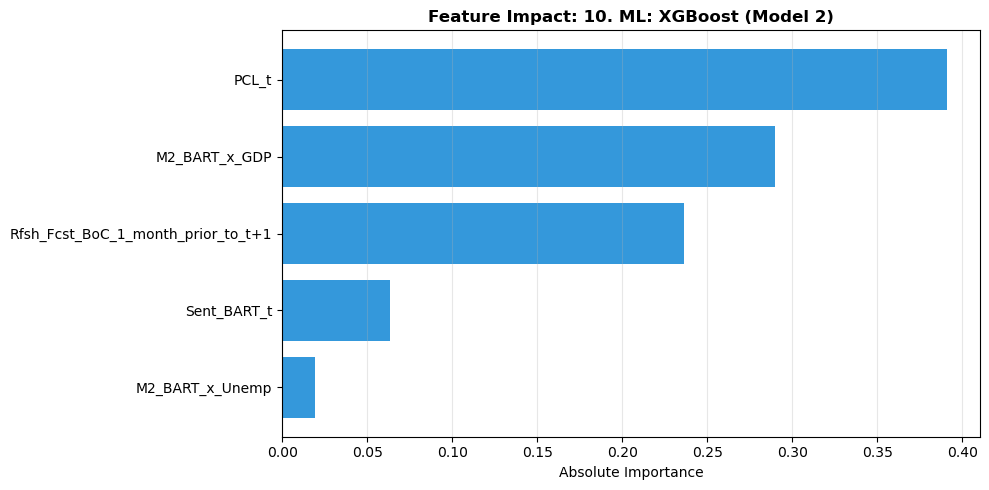


📊 TIME SERIES CHAMPION PARAMETERS (03. TS: VAR (Blind))
   Note: TS models rely on lags (AR) and moving averages (MA).
   The following summary provides academic P-values and coefficients.
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 26, Mar, 2026
Time:                     16:03:48
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    16.4149
Nobs:                     32.0000    HQIC:                   16.0475
Log likelihood:          -378.063    FPE:                7.79677e+06
AIC:                      15.8653    Det(Omega_mle):     5.47592e+06
--------------------------------------------------------------------
Results for equation PCL_t+1
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const             

In [21]:
# ==============================================================================
# [CELL 7.5] MODEL 2 - EXPLAINABILITY (ML FEATURES & TS STATISTICAL SUMMARY)
# ==============================================================================
print(f"\n>>> [Cell 7.5] Deep Dive into Model Explainability...\n")

sc_full2 = StandardScaler()
X_full_sc2 = sc_full2.fit_transform(train_valid_df2[selected_features_m2])
y_full_abs2 = train_valid_df2["PCL_t+1"].values

champ_mod_expl2 = sklearn.base.clone(ml_models_dict[best_ml_m2])
champ_mod_expl2.fit(X_full_sc2, y_full_abs2)

is_tree2 = hasattr(champ_mod_expl2, 'feature_importances_')
importances2 = champ_mod_expl2.feature_importances_ if is_tree2 else champ_mod_expl2.coef_
label_col2 = 'Importance (Tree)' if is_tree2 else 'Coefficient (Linear)'

df_imp2 = pd.DataFrame({'Feature': selected_features_m2, label_col2: importances2})
df_imp2['Abs_Value'] = np.abs(df_imp2[label_col2])
df_imp2 = df_imp2.sort_values(by='Abs_Value', ascending=True)

plt.figure(figsize=(10, 5))
colors2 = '#3498db' if is_tree2 else ['#2ecc71' if val > 0 else '#e74c3c' for val in df_imp2[label_col2]]
plt.barh(df_imp2['Feature'], df_imp2[label_col2], color=colors2)
plt.title(f"Feature Impact: {best_ml_m2} (Model 2)", fontweight='bold')
plt.xlabel("Absolute Importance" if is_tree2 else "Coefficient Value (Red=Negative, Green=Positive)")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

if is_ts_winner2:
    print("\n" + "="*85)
    print(f"📊 TIME SERIES CHAMPION PARAMETERS ({global_best_m2})")
    print("   Note: TS models rely on lags (AR) and moving averages (MA).")
    print("   The following summary provides academic P-values and coefficients.")
    print("="*85)
    try:
        cur_exog2 = pure_exog_m2 if "Pure Macro" in global_best_m2 else exog_m2
        if "VARMAX" in global_best_m2:
            print(VARMAX(train_valid_df2[["PCL_t+1"] + features_ts_hist], exog=train_valid_df2[cur_exog2], order=(1,0)).fit(disp=False).summary())
        elif "VAR" in global_best_m2:
            print(VAR(train_valid_df2[["PCL_t+1"] + features_ts_hist]).fit(maxlags=1).summary())
        elif "ARIMAX" in global_best_m2:
            print(ARIMA(y_full_abs2, exog=train_valid_df2[cur_exog2].values, order=(1,0,0)).fit().summary())
        elif "SARIMA" in global_best_m2:
            print(ARIMA(y_full_abs2, order=(1,0,0)).fit().summary())
    except Exception as e:
        print("Summary generation not available for this specific TS configuration.")

>>> [Cell 8] Deploying Dual-Champions for Model 2...
    🚀 Macro-Sensitive Engine (Base)      : 10. ML: XGBoost
    📏 Global Best Engine (Blind Base)    : 03. TS: VAR (Blind)


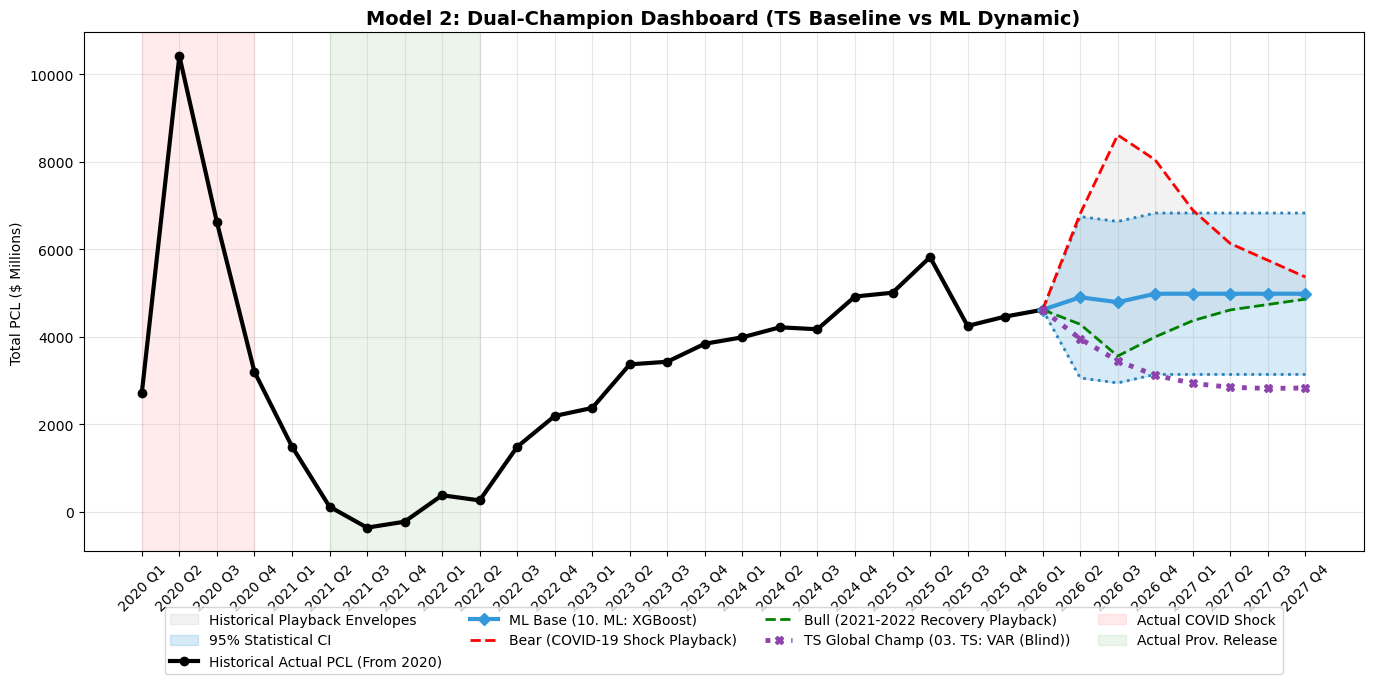

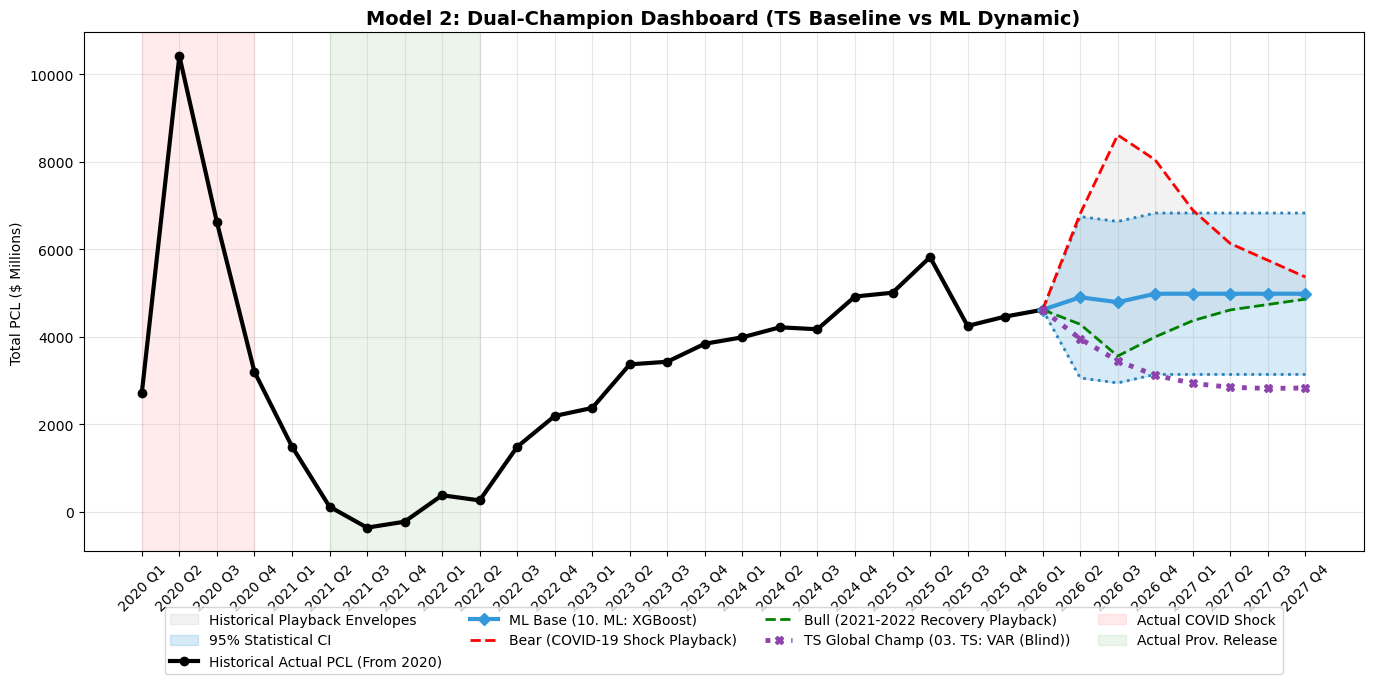

In [22]:
# ==============================================================================
# [CELL 8] MODEL 2 - DUAL-CHAMPION DASHBOARD (EXPERT OVERLAY + TS VS ML)
# ==============================================================================
import os

is_ts_winner2 = global_best_m2 != best_ml_m2

print(f">>> [Cell 8] Deploying Dual-Champions for Model 2...")
print(f"    🚀 Macro-Sensitive Engine (Base)      : {best_ml_m2}")
if is_ts_winner2: print(f"    📏 Global Best Engine (Blind Base)    : {global_best_m2}")

sc_final2 = StandardScaler()
X_final_sc2 = sc_final2.fit_transform(train_valid_df2[selected_features_m2])
y_final_abs2 = train_valid_df2["PCL_t+1"]

champion_model2 = sklearn.base.clone(ml_models_dict[best_ml_m2])
champion_model2.fit(X_final_sc2, y_final_abs2)
best_rmse2 = final_table2[final_table2["Model"] == best_ml_m2]["OOS RMSE"].iloc[0]

file_sheet1 = "Complete_UC2_Forecast_Data.xlsx"
raw_fcst_df = pd.read_excel(file_sheet1, sheet_name="Sheet1")
raw_fcst_df["Year"] = raw_fcst_df["Year"].fillna(0).astype(int)

agg_fcst_funcs = {"GDP YoY Forecast": "mean", "Unemployment Rate YoY QUARTER": "mean", "Overnight Rate": "mean"}
agg_fcst = raw_fcst_df.groupby(["Year", "Quarter"], as_index=False).agg(agg_fcst_funcs).sort_values(["Year", "Quarter"]).reset_index(drop=True)

f_idx = pd.DatetimeIndex(agg_fcst["Year"].astype(str) + "-" + agg_fcst["Quarter"].map({"Q1": "03-31", "Q2": "06-30", "Q3": "09-30", "Q4": "12-31"}))
fc_hor = len(f_idx)

agg_hist_nlp = model2_df["Sent_BART_t"].dropna().values 
try: future_nlp_base = auto_arima(agg_hist_nlp, seasonal=False, suppress_warnings=True).predict(n_periods=fc_hor) if HAS_PMDARIMA else ARIMA(agg_hist_nlp, order=(1,0,0)).fit().forecast(steps=fc_hor)
except: future_nlp_base = np.repeat(agg_hist_nlp[-1], fc_hor)

future_pool_base2 = pd.DataFrame(index=range(fc_hor))
future_pool_base2["Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1"] = agg_fcst["GDP YoY Forecast"].values
future_pool_base2["Unemp_1_month_prior _to_t+1"] = agg_fcst["Unemployment Rate YoY QUARTER"].values
future_pool_base2["Rfsh_Fcst_BoC_1_month_prior_to_t+1"] = agg_fcst["Overnight Rate"].values
future_pool_base2["Sent_BART_t"] = future_nlp_base
future_pool_base2["M2_BART_x_GDP"] = future_nlp_base * agg_fcst["GDP YoY Forecast"].values
future_pool_base2["M2_BART_x_Unemp"] = future_nlp_base * agg_fcst["Unemployment Rate YoY QUARTER"].values
future_pool_base2["M2_BART_x_BoC"] = future_nlp_base * agg_fcst["Overnight Rate"].values
future_pool_base2["PCL_t"] = np.nan 

pcl_base_ml2 = []
curr_pcl2 = last_known_pcl

for i in range(fc_hor):
    future_pool_base2.loc[i, "PCL_t"] = curr_pcl2
    pred = champion_model2.predict(sc_final2.transform(future_pool_base2.iloc[i:i+1][selected_features_m2]))[0]
    pcl_base_ml2.append(pred)
    curr_pcl2 = pred

pcl_base_ml2 = np.array(pcl_base_ml2)

pcl_bear_ml2 = pcl_base_ml2 + (covid_shock_magnitude * playback_curve)
pcl_bull_ml2 = pcl_base_ml2 - (recovery_magnitude * playback_curve)

pcl_upper_ml2 = pcl_base_ml2 + 1.96 * best_rmse2
pcl_lower_ml2 = pcl_base_ml2 - 1.96 * best_rmse2

pcl_base_ts2 = []
if is_ts_winner2:
    cur_exog2 = pure_exog_m2 if "Pure Macro" in global_best_m2 else exog_m2
    if "VARMAX" in global_best_m2:
        try: vmax = VARMAX(train_valid_df2[["PCL_t+1"] + features_ts_hist], exog=train_valid_df2[cur_exog2], order=(1,0)).fit(disp=False); pcl_base_ts2 = vmax.forecast(steps=fc_hor, exog=future_pool_base2[cur_exog2]).iloc[:, 0].values
        except: pcl_base_ts2 = np.repeat(last_known_pcl, fc_hor)
    elif "VAR" in global_best_m2:
        try: var_mod2 = VAR(train_valid_df2[["PCL_t+1"] + features_ts_hist]).fit(maxlags=1); pcl_base_ts2 = var_mod2.forecast(train_valid_df2[["PCL_t+1"] + features_ts_hist].values[-1:], steps=fc_hor)[:, 0]
        except: pcl_base_ts2 = np.repeat(last_known_pcl, fc_hor)
    elif "ARIMAX" in global_best_m2:
        try: arimax_m = ARIMA(train_valid_df2["PCL_t+1"].values, exog=train_valid_df2[cur_exog2].values, order=(1,0,0)).fit(); pcl_base_ts2 = arimax_m.forecast(steps=fc_hor, exog=future_pool_base2[cur_exog2].values)
        except: pcl_base_ts2 = np.repeat(last_known_pcl, fc_hor)
    elif "SARIMA" in global_best_m2:
        try: pcl_base_ts2 = ARIMA(train_valid_df2["PCL_t+1"].values, order=(1,0,0)).fit().forecast(steps=fc_hor)
        except: pcl_base_ts2 = np.repeat(last_known_pcl, fc_hor)
    else: pcl_base_ts2 = np.repeat(last_known_pcl, fc_hor)

plt.close('all'); fig_fan, ax_fan = plt.subplots(figsize=(14, 7))

ax_fan.fill_between(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_bear_ml2), [np.nan]*pad_length+[last_known_pcl]+list(pcl_bull_ml2), alpha=0.10, color='gray', label="Historical Playback Envelopes")
ax_fan.fill_between(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_lower_ml2), [np.nan]*pad_length+[last_known_pcl]+list(pcl_upper_ml2), alpha=0.20, color='#3498db', label="95% Statistical CI")

ax_fan.plot(x_ticks, y_hist, 'k-o', label="Historical Actual PCL (From 2020)", linewidth=3.0)
ax_fan.plot(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_upper_ml2), color='#2980b9', linestyle=':', linewidth=2.0)
ax_fan.plot(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_lower_ml2), color='#2980b9', linestyle=':', linewidth=2.0)

ax_fan.plot(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_base_ml2), color='#3498db', marker='D', label=f"ML Base ({best_ml_m2})", linewidth=3.0)
ax_fan.plot(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_bear_ml2), 'r--', label="Bear (COVID-19 Shock Playback)", linewidth=2.0)
ax_fan.plot(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_bull_ml2), 'g--', label="Bull (2021-2022 Recovery Playback)", linewidth=2.0)

if is_ts_winner2:
    ax_fan.plot(x_ticks, [np.nan]*pad_length+[last_known_pcl]+list(pcl_base_ts2), color='#8e44ad', marker='X', linestyle=':', label=f"TS Global Champ ({global_best_m2})", linewidth=3.5)

try:
    c_start, c_end = list(hist_dates).index(pd.to_datetime("2020-03-31")), list(hist_dates).index(pd.to_datetime("2020-12-31"))
    ax_fan.axvspan(c_start, c_end, color='red', alpha=0.08, label="Actual COVID Shock")
    r_start, r_end = list(hist_dates).index(pd.to_datetime("2021-06-30")), list(hist_dates).index(pd.to_datetime("2022-06-30"))
    ax_fan.axvspan(r_start, r_end, color='green', alpha=0.08, label="Actual Prov. Release")
except: pass

ax_fan.set_xticks(x_ticks); ax_fan.set_xticklabels(x_labels, rotation=45)
ax_fan.set_title(f"Model 2: Dual-Champion Dashboard (TS Baseline vs ML Dynamic)", fontweight="bold", fontsize=14)
ax_fan.set_ylabel("Total PCL ($ Millions)"); ax_fan.grid(True, alpha=0.3); ax_fan.legend(loc="lower center", ncol=4 if is_ts_winner2 else 3, bbox_to_anchor=(0.5, -0.25))
plt.tight_layout(); display(fig_fan)

ui_out2 = widgets.Output()
drop2 = widgets.Dropdown(options=q_str_list, description='Future Quarter:')

def update_ui2(change):
    selected_str = change.new if hasattr(change, 'new') else change
    idx_pos = q_str_list.index(selected_str)
    
    with ui_out2:
        clear_output(wait=True)
        feature_rows_html = ""
        for feat in selected_features_m2:
            val = future_pool_base2.loc[idx_pos, feat]
            feature_rows_html += f"<tr style='border-bottom:1px solid #eee;'><td><b>{feat}</b></td><td style='text-align:right;'>{val:,.2f}</td></tr>"

        ts_box_html = ""
        if is_ts_winner2:
            ts_box_html = f"""
            <div style="background:#F4ECF7; padding:10px; border-radius:5px; margin: 15px 0 5px 0; border-left: 4px solid #8e44ad;">
                <b style="color:#2C3E50;">TS Global Champ ({global_best_m2}):</b> <span style="float:right; font-weight:bold; font-size:1.1em; color:#8e44ad;">${pcl_base_ts2[idx_pos]:,.0f}</span>
                <div style="clear:both;"></div>
                <p style="font-size:0.8em; color:#7F8C8D; margin:4px 0 0 0; text-align:right;">*Control Model Forecast</p>
            </div>
            """

        html_str = f"""
        <div style="font-family:sans-serif; border:2px solid #2C3E50; border-radius:12px; padding:15px; max-width:950px;">
            <h2 style="color:#2C3E50; text-align:center; border-bottom:2px solid #BDC3C7;">🏦 Model 2 Direct PCL Dashboard<br><span style="font-size:16px;">Quarter: {selected_str}</span></h2>
            <div style="display:flex; justify-content:space-between;">
                <div style="width:48%;">
                    <h3 style="color:#2C3E50;">🎯 Final Projections ($M)</h3>
                    
                    <p style="color:#c0392b; margin:4px 0;">🔴 <b>Bear (COVID Playback):</b> <span style="float:right; font-weight:bold;">${pcl_bear_ml2[idx_pos]:,.0f}</span></p>
                    <p style="color:#2980b9; margin:4px 0; font-size: 0.9em;">🔺 <b>95% CI Upper Bound:</b> <span style="float:right;">${pcl_upper_ml2[idx_pos]:,.0f}</span></p>
                    
                    <div style="background:#D6EAF8; padding:10px; border-radius:5px; margin: 10px 0; border-left: 4px solid #3498db;">
                        <b style="color:#2C3E50;">ML Base ({best_ml_m2}):</b> <span style="float:right; font-weight:bold; font-size:1.1em; color:#2980b9;">${pcl_base_ml2[idx_pos]:,.0f}</span>
                        <div style="clear:both;"></div>
                    </div>
                    
                    <p style="color:#2980b9; margin:4px 0; font-size: 0.9em;">🔻 <b>95% CI Lower Bound:</b> <span style="float:right;">${pcl_lower_ml2[idx_pos]:,.0f}</span></p>
                    <p style="color:#27ae60; margin:4px 0;">🟢 <b>Bull (Recovery Playback):</b> <span style="float:right; font-weight:bold;">${pcl_bull_ml2[idx_pos]:,.0f}</span></p>
                    
                    {ts_box_html}
                </div>
                
                <div style="width:48%; border-left:2px dashed #BDC3C7; padding-left:15px;">
                    <h3 style="color:#2980b9;">📊 Features Driving the Forecast</h3>
                    <table style="width:100%; font-size:12px; border-collapse:collapse;">
                        <tr style="color:#7F8C8D; border-bottom:1px solid #ccc;"><th align="left">Feature</th><th style="text-align:right;">Assumed Value</th></tr>
                        {feature_rows_html}
                    </table>
                </div>
            </div>
        </div>
        """
        display(HTML(html_str))

drop2.observe(update_ui2, names='value')
display(widgets.VBox([drop2, ui_out2]))
update_ui2(drop2.value)

# CSV

In [23]:
# ==============================================================================
# [CELL 9] EXPORT FORECAST RESULTS TO CSV FOR TEAM INTEGRATION
# ==============================================================================
import pandas as pd

print(">>> [Cell 9] Exporting final forecast scenarios to CSV for team integration...")

export_df = pd.DataFrame({
    "Quarter": q_str_list,
    "Model1_ML_Base": pcl_base_ml1,
    "Model1_Bear_COVID": pcl_bear_ml1,
    "Model1_Bull_Recovery": pcl_bull_ml1,
    "Model1_95CI_Lower": pcl_lower_ml1,
    "Model1_95CI_Upper": pcl_upper_ml1,
    "Model2_ML_Base": pcl_base_ml2,
    "Model2_Bear_COVID": pcl_bear_ml2,
    "Model2_Bull_Recovery": pcl_bull_ml2,
    "Model2_95CI_Lower": pcl_lower_ml2,
    "Model2_95CI_Upper": pcl_upper_ml2,
})

if is_ts_winner1: export_df["Model1_TS_Global_Champ"] = pcl_base_ts1
if is_ts_winner2: export_df["Model2_TS_Global_Champ"] = pcl_base_ts2

export_numeric_cols = [c for c in export_df.columns if c != "Quarter"]
export_df[export_numeric_cols] = export_df[export_numeric_cols].round(1)

csv_filename = "PCL_Final_Forecast_Scenarios.csv"
export_df.to_csv(csv_filename, index=False)

print(f"✅ Success! All forecast scenarios have been cleanly saved to '{csv_filename}'.")
display(export_df.style.format(precision=1).set_properties(**{'text-align': 'center', 'border': '1px solid #ddd'}).hide(axis="index"))

>>> [Cell 9] Exporting final forecast scenarios to CSV for team integration...
✅ Success! All forecast scenarios have been cleanly saved to 'PCL_Final_Forecast_Scenarios.csv'.


Quarter,Model1_ML_Base,Model1_Bear_COVID,Model1_Bull_Recovery,Model1_95CI_Lower,Model1_95CI_Upper,Model2_ML_Base,Model2_Bear_COVID,Model2_Bull_Recovery,Model2_95CI_Lower,Model2_95CI_Upper,Model1_TS_Global_Champ,Model2_TS_Global_Champ
2026 Q2,4783.6,6696.1,4167.1,2643.2,6924.0,4903.3,6815.8,4286.8,3057.0,6749.5,3953.7,3953.7
2026 Q3,4797.1,8622.1,3564.1,2656.7,6937.5,4791.4,8616.4,3558.4,2945.2,6637.7,3448.3,3448.3
2026 Q4,4960.3,8020.3,3973.9,2819.9,7100.7,4984.7,8044.7,3998.3,3138.5,6831.0,3120.8,3120.8
2027 Q1,4941.9,6854.4,4325.4,2801.5,7082.3,4984.7,6897.2,4368.2,3138.5,6831.0,2934.0,2934.0
2027 Q2,4910.6,6058.1,4540.7,2770.1,7051.0,4984.7,6132.2,4614.8,3138.5,6831.0,2844.8,2844.8
2027 Q3,4822.9,5587.9,4576.3,2682.4,6963.3,4984.7,5749.7,4738.1,3138.5,6831.0,2818.2,2818.2
2027 Q4,4791.5,5174.0,4668.2,2651.1,6932.0,4984.7,5367.2,4861.4,3138.5,6831.0,2828.7,2828.7
